In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpdaf.obj import Cube
from astropy.coordinates import SkyCoord
import sys
import os
import plotfancy as pf
from matplotlib.patches import Circle, ConnectionPatch, FancyArrowPatch, Arrow
from astropy.visualization import ZScaleInterval

import seaborn as sns

from types import SimpleNamespace
import re
from astropy.io import ascii, fits
from astropy import units as u
from astropy.constants import c as speedoflight
from astropy.table import Table, vstack, hstack, join, Column, unique
from scipy.optimize import curve_fit, root
from astropy.cosmology import Planck18 as cosmo
from astropy import coordinates as coords
from astroquery.sdss import SDSS
from requests.exceptions import ConnectionError
from matplotlib.lines import Line2D
# from hst_phot import *
from prospect.models.templates import TemplateLibrary
from prospect.models import SpecModel
import prospect.fitting as fitting
from prospect.io import write_results as writer
import prospect.io.read_results as reader
from prospect.sources import CSPSpecBasis
from prospect.models import priors
from genesis_metallicity.genesis_metallicity import genesis_metallicity
from mpl_toolkits.axes_grid1.inset_locator import mark_inset, zoomed_inset_axes
from tqdm import tqdm
import seaborn as sns
plt.rcParams['text.usetex'] = False
pf.housestyle_rcparams()

# from calculate_jiang19_metallicity import calculate_metallicity_jiang19 as cjm19
sys.path.append('../../../')
import src.ifu_tools.line_ratios as lr
import src.ifu_tools.ifutools as ift

import logging 
logging.getLogger('mpdaf').setLevel(logging.WARNING)

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings('ignore', message='The following kwargs were not used by contour')



In [2]:
def calculate_cluster_metrics(tbl):
    """
    Calculates LoS velocity, angular separation, projected distance, and 3D distance from a cluster center.

    Parameters:
    tbl (astropy.table.Table): Table with columns 'ra', 'dec', 'cluster_ra', 'cluster_dec', 'z', 'zcluster'.

    Returns:
    astropy.table.Table: Table with new columns 'los_velocity_kms', 'angular_separation_arcsec', 
                         'projected_distance_mpc', and 'distance_3d_mpc'.
    """
    c = 299792.458  # Speed of light in km/s

    # Calculate Line of Sight (LoS) velocity
    tbl['los_velocity_kms'] = c * (tbl['z'] - tbl['zcluster']) / (1 + tbl['zcluster'])
    tbl['los_velocity_kms'].unit = 'km/s'

    # Calculate angular separation
    galaxy_coords = SkyCoord(tbl['ra'], tbl['dec'], unit='deg', frame='icrs')
    cluster_coords = SkyCoord(tbl['cluster_ra'], tbl['cluster_dec'], unit='deg', frame='icrs')
    angular_separation = galaxy_coords.separation(cluster_coords)
    tbl['angular_separation_arcsec'] = angular_separation.arcsec
    tbl['angular_separation_arcsec'].unit = 'arcsec'

    # Calculate projected physical distance
    # Using the angular diameter distance to the cluster
    D_A = cosmo.angular_diameter_distance(tbl['zcluster'])
    # Small angle approximation: distance = angular_separation_in_radians * D_A
    tbl['projected_distance_mpc'] = (angular_separation.radian * D_A).to(u.Mpc)
    tbl['projected_distance_mpc'].unit = 'Mpc'

    # Calculate 3D distance
    d_c = cosmo.comoving_distance(tbl['zcluster'])
    d_g = cosmo.comoving_distance(tbl['z'])
    
    # Law of cosines
    distance_3d_sq = d_c**2 + d_g**2 - 2 * d_c * d_g * np.cos(angular_separation.radian)
    tbl['distance_3d_mpc'] = np.sqrt(distance_3d_sq.value) * u.Mpc
    tbl['distance_3d_mpc'].unit = 'Mpc'

    return tbl

In [3]:
MASTER1 = Table(ascii.read('../catalogue/MASTER_preLSD.csv'))
MASTER2 = Table(ascii.read('../catalogue/MASTER.csv'))
REFCAT = Table(ascii.read('cube_info.csv'))
REFCAT.add_index('cluster_key')
REFCAT_headers = ['name','object_fullname','cluster_ra','cluster_dec','source_dir']
refm1 = MASTER1.copy()
refm2 = MASTER2.copy()

for M in [MASTER1,MASTER2]:
    M['oii_flux'] = M['oii3729_flux'] + M['oii3726_flux']
    M['oii_ew'] = M['oii3729_ew'] + M['oii3726_ew']
    condition = np.isfinite(M['oiii5007_ew']) | np.isfinite(M['oii_ew'])
    M = M[condition]
    # M = M[np.isfinite(M['oiii5007_ew'])]
    M = M[(M['oiii4959_flux']/M['oiii5007_flux'])>0.1]
    M['oiii4959_flux'] = M['oiii5007_flux']/3

MASTER = vstack([MASTER1,MASTER2])

for r in ['cluster_key', 'cluster_fullname', 'source_dir']:
    MASTER[r] = 'blankblankblankblank'

for r in ['cluster_ra', 'cluster_dec']:
    MASTER[r] = np.nan

for m in MASTER:
    REFCAT_ROW = REFCAT.loc[m['name']]
    for r in REFCAT.colnames:
        m[r] = REFCAT_ROW[r]

MASTER = calculate_cluster_metrics(MASTER)

MUSEWIDE = Table(ascii.read('final_table.csv'))
MUSEWIDE['z'] = MUSEWIDE['Z'] #alias


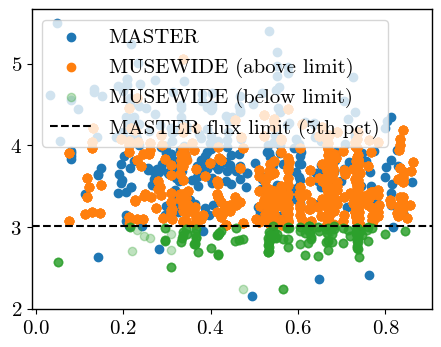

In [4]:
# Derive flux limit from MASTER (e.g. 5th percentile to capture the faint end)
flux_limit = np.nanpercentile(MASTER['oiii5007_flux'], 5)

# Flag MUSEWIDE sources below the MASTER flux limit
MUSEWIDE['above_master_limit'] = MUSEWIDE['WFoiii5007_flux'] >= flux_limit

# Plot
fig, ax = pf.create_plot()

ax.scatter(MASTER['z'], np.log10(MASTER['oiii5007_flux']), label='MASTER')

above = MUSEWIDE[MUSEWIDE['above_master_limit']]
below = MUSEWIDE[~MUSEWIDE['above_master_limit']]

ax.scatter(above['z'], np.log10(above['WFoiii5007_flux']), label='MUSEWIDE (above limit)')
ax.scatter(below['z'], np.log10(below['WFoiii5007_flux']), label='MUSEWIDE (below limit)', alpha=0.3)

ax.axhline(np.log10(flux_limit), color='k', linestyle='--', label=f'MASTER flux limit (5th pct)')
ax.legend()

######OPTIONAL######
# MUSEWIDE = MUSEWIDE[MUSEWIDE['above_master_limit']]



In [5]:
######################################################
# SANITY CHECK - CHECK DECREMENT 
######################################################

# ── Atomic data ───────────────────────────────────────────────────────────────

# Intrinsic Balmer ratios relative to Hβ (Case B, T=10^4 K, ne=100 cm^-3)
# from Osterbrock & Ferland (2006)
BALMER_INTRINSIC = {
    "halpha":   (6563.0, 2.86),
    "hgamma":   (4340.0, 0.468),
    "hdelta":   (4102.0, 0.259),
    "hepsilon": (3970.0, 0.160),
    "hzeta":    (3889.0, 0.105),
    "heta":     (3835.0, 0.0731),
}
# Hβ anchor
HB_WAVE = 4861.0


def k_calzetti(wavelength_angstrom):
    """Calzetti et al. (2000) attenuation curve k(λ). Input in Angstroms."""
    lam = np.atleast_1d(np.asarray(wavelength_angstrom, dtype=float))
    mu = lam * 1e-4  # Å → µm
    k = np.full_like(mu, np.nan)

    blue = (mu >= 0.12) & (mu < 0.63)
    k[blue] = (2.659 * (-2.156 + 1.509 / mu[blue]
                         - 0.198 / mu[blue] ** 2
                         + 0.011 / mu[blue] ** 3) + 4.05)

    red = (mu >= 0.63) & (mu <= 2.20)
    k[red] = 2.659 * (-1.857 + 1.040 / mu[red]) + 4.05

    return float(k.squeeze()) if k.size == 1 else k


# Pre-compute k values for all Balmer lines and Hβ
K_HB = k_calzetti(HB_WAVE)
BALMER_K = {name: k_calzetti(wave) for name, (wave, _) in BALMER_INTRINSIC.items()}


# ── E(B-V) from a single Balmer pair ─────────────────────────────────────────

def ebv_from_pair(f_line, f_hb, intrinsic_ratio, k_line, k_hb=K_HB):
    """
    E(B-V) from one observed Balmer line flux and Hβ.

    Returns NaN if the inputs are non-finite, non-positive, or
    if the decrement implies unphysical (negative) reddening.
    """
    f_line = np.asarray(f_line, dtype=float)
    f_hb   = np.asarray(f_hb,   dtype=float)

    with np.errstate(invalid="ignore", divide="ignore"):
        ratio = f_line / f_hb
        ebv = 2.5 * np.log10(ratio / intrinsic_ratio) / (k_hb - k_line)

    ebv = np.where((ratio > 0) & np.isfinite(ebv), ebv, np.nan)
    ebv = np.where(ebv < 0, 0.0, ebv)   # clamp unphysical values
    return ebv


# ── Best-available E(B-V) per row ────────────────────────────────────────────

def best_ebv(df: pd.DataFrame) -> pd.DataFrame:
    """
    For each row, compute E(B-V) from every available Balmer decrement
    (line / Hβ), then pick the estimate with the highest combined S/N.

    Adds columns:
        EBV          – best E(B-V) estimate
        EBV_line     – which Balmer line was used (e.g. 'halpha')
        EBV_snr      – combined S/N of the pair used  (min of the two S/Ns)

    Returns a copy of df with those columns appended.
    """
    df = df.copy()
    n = len(df)

    best_ebv_arr  = np.full(n, np.nan)
    best_line_arr = np.full(n, "", dtype=object)
    best_snr_arr  = np.full(n, -np.inf)

    hb_flux = df["hbeta_flux"].values
    hb_err  = df["hbeta_flux_err"].values
    hb_snr  = np.where(hb_err > 0, hb_flux / hb_err, np.nan)

    for line, (_, intrinsic) in BALMER_INTRINSIC.items():
        flux_col = f"{line}_flux"
        err_col  = f"{line}_flux_err"
        if flux_col not in df.columns or err_col not in df.columns:
            continue

        f   = df[flux_col].values
        err = df[err_col].values

        line_snr = np.where(err > 0, f / err, np.nan)

        # Use the *minimum* S/N of the pair as the quality metric —
        # the weakest link limits how well we can constrain E(B-V)
        pair_snr = np.minimum(line_snr, hb_snr)

        ebv_vals = ebv_from_pair(f, hb_flux, intrinsic, BALMER_K[line])

        # Update wherever this pair gives a finite E(B-V) and better S/N
        better = (
            np.isfinite(ebv_vals)
            & np.isfinite(pair_snr)
            & (pair_snr > best_snr_arr)
        )
        best_ebv_arr  = np.where(better, ebv_vals,  best_ebv_arr)
        best_snr_arr  = np.where(better, pair_snr,  best_snr_arr)
        best_line_arr = np.where(better, line,       best_line_arr)

    df["EBV"]      = best_ebv_arr
    df["EBV_line"] = best_line_arr
    df["EBV_snr"]  = np.where(np.isfinite(best_snr_arr), best_snr_arr, np.nan)

    return df


# ── Correction ────────────────────────────────────────────────────────────────

LINE_WAVES = {
    "oiii5007":  5007.0,
    "oiii4959":  4959.0,
    "oii3726":   3726.0,
    "oii3729":   3729.0,
    "halpha":    6563.0,
    "hbeta":     4861.0,
    "hgamma":    4340.0,
    "hdelta":    4102.0,
    "hepsilon":  3970.0,
    "hzeta":     3889.0,
    "heta":      3835.0,
    "oiii4363":  4363.0,
    "neiii":     3869.0,
    "nii6583":   6583.0,
    "nii6548":   6548.0,
    "sii6716":   6716.0,
    "sii6731":   6731.0,
    "nev3426":   3426.0,
    "fevii3760": 3760.0,
    "heii4686":  4686.0,
    "hei5876":   5876.0,
}


def calzetti_correction(flux, wavelength_angstrom, ebv):
    k = k_calzetti(wavelength_angstrom)
    return np.asarray(flux, dtype=float) * 10 ** (0.4 * ebv * k)


def correct_table(df: pd.DataFrame) -> pd.DataFrame:
    """
    Full pipeline: compute best-available E(B-V) per row, then
    apply Calzetti correction to every recognised line flux.
    Adds '<line>_flux_corr' columns plus EBV / EBV_line / EBV_snr.
    """
    df = best_ebv(df)

    for line, wave in LINE_WAVES.items():
        col = f"{line}_flux"
        if col not in df.columns:
            continue
        df[f"{line}_flux_corr"] = calzetti_correction(
            df[col].values, wave, df["EBV"].values
        )

    return df


# ── Demo ──────────────────────────────────────────────────────────────────────
df = MASTER.to_pandas()
df_corrected = correct_table(df)
#OPTIONAL 
MASTER = Table.from_pandas(df_corrected)

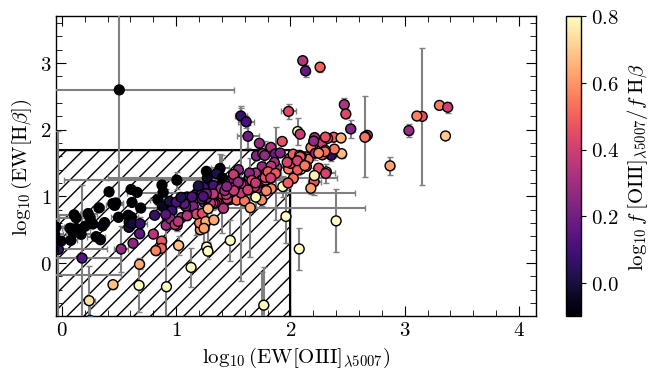

In [6]:
tab = MASTER

fig, ax = pf.create_plot((6,3))
err_x = 0.434*(tab['oiii5007_ew_err']/(tab['oiii5007_ew']))
err_y = 0.434*np.abs(tab['hbeta_ew_err']/(tab['hbeta_ew']))

err_y[err_y>1]=1+np.random.normal(0,0.55, size=len(err_y[err_y>1]))
err_x[err_x>1]=1

oiiihbeta = np.log10(tab['oiii5007_flux']/tab['hbeta_flux'])


cbar = ax.scatter(np.log10(tab['oiii5007_ew']),np.log10(tab['hbeta_ew']), c=oiiihbeta+np.random.normal(loc=0,scale=.1),s=50, zorder=10, cmap='magma', vmin=-0.1,vmax=0.8, ec='k')
ax.errorbar(np.log10(tab['oiii5007_ew']),np.log10(tab['hbeta_ew']), 
            yerr = err_y, xerr=err_x,
            mfc='None', zorder=9, ecolor='gray', capsize=2, fmt='o')

plt.colorbar(cbar, label=r'$\log_{10}f\;$[OIII]$_{\lambda5007}/f\;$H$\beta$')

ax.set_xlabel(r'$\log_{10}($EW[OIII]$_{\lambda5007}$)')
ax.set_ylabel(r'$\log_{10}($EW[H$\beta$])')

ax.set_xlim(-0.05, 4.15)
ax.set_ylim(-0.8, 3.7)

ax.vlines(2,-100,np.log10(50),color='k')
ax.hlines(np.log10(50),-100,2,color='k')
ax.fill_between([-100,2],-100,np.log10(50), facecolor='white', edgecolor='black', zorder=-10, hatch='//')

pf.fix_plot([ax])
fig.savefig(f'figs/populations.png', dpi=600, bbox_inches='tight')

In [7]:
def do_langeroodi_me(INPUT_TABLE):
    COPY = INPUT_TABLE.copy()
    COPY['Z_dir_gen'] = np.ones_like(COPY['z'])*1.031492
    COPY['Z_dir_gen_err'] = np.ones_like(COPY['z'])*1.031492
    COPY['direct'] = np.ones_like(COPY['z'])

    COPY_MASK = (
        (COPY['oii3726_flux'] > 0) &
        (COPY['oii3729_flux'] > 0) &
        (COPY['hbeta_flux'] > 0) &
        (COPY['oiii5007_flux'] > 0) &
        (COPY['oiii4959_flux'] > 0)
    )
    COPY_CLEAN = COPY[COPY_MASK].copy()

    for p in tqdm(COPY_CLEAN):
        input_dict = {}
        input_dict['redshift'] =  p['z']
        input_dict['OII']      = [p['oii3726_flux']+p['oii3729_flux'], np.sqrt(np.sum(np.array([p['oii3726_flux_err'], p['oii3729_flux_err']])**2))]
        input_dict['Hbeta']    = [p['hbeta_flux'], p['hbeta_flux_err']]
        input_dict['O4959']    = [p['oiii5007_flux']/3, p['oiii4959_flux_err']]
        input_dict['O5007']    = [p['oiii5007_flux'], p['oiii5007_flux_err']]
        input_dict['Hbeta_EW'] = [p['hbeta_ew'], p['hbeta_ew_err']]

        # Optional lines — only include if flux > 0
        if p['hdelta_flux'] > 0:
            input_dict['Hdelta'] = [p['hdelta_flux'], p['hdelta_flux_err']]
        if p['hgamma_flux'] > 0:
            input_dict['Hgamma'] = [p['hgamma_flux'], p['hgamma_flux_err']]

        try:
            galaxy = genesis_metallicity(input_dict)
            p['Z_dir_gen'] = galaxy.metallicity.n
            p['Z_dir_gen_err'] = galaxy.metallicity.s
        except:
            print('failed')
            p['Z_dir_gen'] = np.nan
            p['Z_dir_gen_err'] = np.nan
        
    return COPY_CLEAN
    
def do_langeroodi_mw(INPUT_TABLE):
    COPY = INPUT_TABLE.copy()
    COPY['Z_dir_gen'] = np.ones_like(COPY['z'])*1.031492
    COPY['Z_dir_gen_err'] = np.ones_like(COPY['z'])*1.031492
    COPY['direct'] = np.ones_like(COPY['z'])

    COPY_MASK = (
        (COPY['WFoii_flux'] > 0) &
        (COPY['WFhbeta_flux'] > 0) &
        (COPY['WFoiii5007_flux'] > 0) &
        (COPY['WFoiii4959_flux'] > 0)
    )
    COPY_CLEAN = COPY[COPY_MASK].copy()

    for p in tqdm(COPY_CLEAN):
        input_dict = {}
        input_dict['redshift'] =  p['z']
        input_dict['OII']      = [p['WFoii_flux'], p['WFoii_flux_err']]
        input_dict['Hbeta']    = [p['WFhbeta_flux'], p['WFhbeta_flux_err']]
        input_dict['O4959']    = [p['WFoiii4959_flux'], p['WFoiii4959_flux_err']]
        input_dict['O5007']    = [p['WFoiii5007_flux'], p['WFoiii5007_flux_err']]
        input_dict['Hbeta_EW'] = [p['WFhbeta_ew'], 1]

        try:
            galaxy = genesis_metallicity(input_dict)
            p['Z_dir_gen'] = galaxy.metallicity.n
            p['Z_dir_gen_err'] = galaxy.metallicity.s
        except:
            print('failed')
            p['Z_dir_gen'] = np.nan
            p['Z_dir_gen_err'] = np.nan
        
    return COPY_CLEAN

def get_sfr(hbeta_fluxes, z):
    lum_d = cosmo.luminosity_distance(z).to(u.cm).value
    lum_hb = (hbeta_fluxes*1e-20)*4*np.pi*lum_d**2
    lum_ha = 2.86*lum_hb
    sfr = 7.9*1e-42*lum_ha
    return np.log10(sfr)

In [8]:
MASTER_CLEAN = do_langeroodi_me(MASTER)
MUSEWIDE_CLEAN = do_langeroodi_mw(MUSEWIDE)

 54%|█████▍    | 105/195 [00:22<00:19,  4.55it/s]

failed


100%|██████████| 732/732 [02:28<00:00,  4.94it/s]


In [9]:
MASTER_CLEAN['logSFR'] = get_sfr(MASTER_CLEAN['hbeta_flux'],MASTER_CLEAN['z'])
MUSEWIDE_CLEAN['logSFR'] = get_sfr(MUSEWIDE_CLEAN['WFhbeta_flux'],MUSEWIDE_CLEAN['Z'])

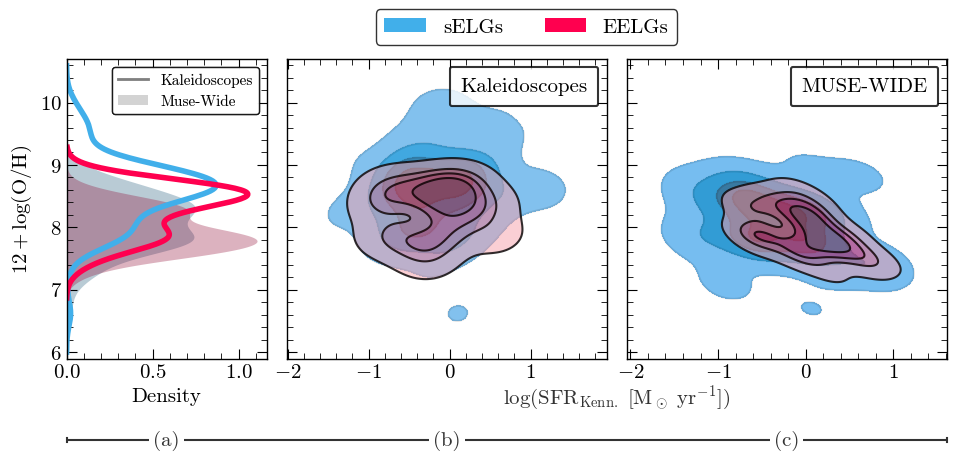

In [ ]:
MUSEWIDE_CLEAN_DEDUP = unique(MUSEWIDE_CLEAN, keys='UNIQUE_ID', keep='first')

PEAS_MASK = (np.log10(MASTER_CLEAN['oiii5007_ew'])>2)|(np.log10(MASTER_CLEAN['hbeta_ew'])>np.log10(50))
PEAS = MASTER_CLEAN[PEAS_MASK]
NONPEAS = MASTER_CLEAN[~PEAS_MASK]

MW_PEAS_MASK = (np.log10(MUSEWIDE_CLEAN_DEDUP['WFoiii5007_ew'])>2)&(np.log10(MUSEWIDE_CLEAN_DEDUP['WFhbeta_ew'])>np.log10(50))
MW_PEAS = MUSEWIDE_CLEAN_DEDUP[MW_PEAS_MASK]
MW_NONPEAS = MUSEWIDE_CLEAN_DEDUP[~MW_PEAS_MASK]

fig, ax = pf.create_plot((2,3))
ax2 = fig.add_axes((1.1,0,1.6,1),sharey=ax)
ax3 = fig.add_axes((2.8,0,1.6,1),sharey=ax)
plt.setp(ax2.get_yticklabels(), visible=False)
plt.setp(ax3.get_yticklabels(), visible=False)

ax.set_xlabel('Density')
ax.set_ylabel(r'$12+\log(\mathrm{O/H})$')
ax2.set_xlabel(r'$\log($SFR$_{\mathrm{Kenn.}}$ [M$_{\odot}$ yr$^{-1}$])')

#######################################
# AXIS 1 #
#######################################

##### KALEIDOSCOPE #####
sns.kdeplot(y=NONPEAS['Z_dir_gen'], ax=ax, c='#41afea', lw=4, label='sELGs')
sns.kdeplot(y=PEAS['Z_dir_gen'], ax=ax, c='#ff004f', lw=4, label='EELGs')

##### MUSEWIDE #####
sns.kdeplot(y=MW_NONPEAS['Z_dir_gen'], ax=ax, color="#175475ff", lw=0, label='sELGs', fill=True, alpha=0.3, zorder=-10,)
sns.kdeplot(y=MW_PEAS['Z_dir_gen'], ax=ax, color="#8e012dff", lw=0, label='EELGs', fill=True, alpha=0.3,zorder=-10,)

#######################################
# AXIS 2 #
#######################################

LEVELS = 5

##### KALEIDOSCOPE #####
sns.kdeplot(x=NONPEAS['logSFR'], y=NONPEAS['Z_dir_gen'], ax=ax2, color='#41afea', label='sELGs', fill=True, alpha=1, zorder=-10, levels=LEVELS)
sns.kdeplot(x=NONPEAS['logSFR'], y=NONPEAS['Z_dir_gen'], ax=ax2, color='k', lw=1, fill=False, alpha=0.1, zorder=-8, levels=LEVELS)
sns.kdeplot(x=PEAS['logSFR'], y=PEAS['Z_dir_gen'], ax=ax2, color='#ff004f', label='EELGs', fill=True, alpha=0.5, zorder=10, levels=LEVELS)
sns.kdeplot(x=PEAS['logSFR'], y=PEAS['Z_dir_gen'], ax=ax2, color='k', lw=1, fill=False, alpha=0.8, zorder=10, levels=LEVELS)

#######################################
# AXIS 3 #
#######################################

##### MUSEWIDE #####
sns.kdeplot(x=MW_NONPEAS['logSFR'], y=MW_NONPEAS['Z_dir_gen'], ax=ax3, color='#175475ff', label='sELGs', fill=True, alpha=1, zorder=-10, levels=LEVELS)
sns.kdeplot(x=MW_NONPEAS['logSFR'], y=MW_NONPEAS['Z_dir_gen'], ax=ax3, color='k', lw=1, fill=False, alpha=0.1, zorder=-8, levels=LEVELS)
sns.kdeplot(x=MW_PEAS['logSFR'], y=MW_PEAS['Z_dir_gen'], ax=ax3, color='#8e012dff', label='EELGs', fill=True, alpha=0.5, zorder=10, levels=LEVELS)
sns.kdeplot(x=MW_PEAS['logSFR'], y=MW_PEAS['Z_dir_gen'], ax=ax3, color='k', lw=1, fill=False, alpha=0.8, zorder=10, levels=LEVELS)


##########

from matplotlib.offsetbox import AnchoredText

for ax_, label in [(ax2, r'Kaleidoscopes'), (ax3, 'MUSE-WIDE')]:
    at = AnchoredText(
        label,
        loc='upper right',
        prop=dict(size=15, fontweight='bold'),
        frameon=True,
        pad=0.4,
    )
    at.patch.set_boxstyle("round,pad=0.1")
    at.patch.set_edgecolor('black')
    at.patch.set_linewidth(1.5)
    at.patch.set_facecolor('white')
    at.patch.set_alpha(0.8)
    ax_.add_artist(at)

##########################

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.legend import Legend

# Survey style indicators
survey_handles = [
    Line2D([0], [0], color='grey', lw=2, label=r'Kaleidoscopes'),
    Patch(facecolor='grey', alpha=0.3, label=r'Muse-Wide'),
]
pop_handles = [
    Patch(facecolor='#41afea', label=r'sELGs'),
    Patch(facecolor='#ff004f', label=r'EELGs'),
]

# Population legend — 2 cols, anchored above the whole figure
fig.legend(handles=pop_handles, loc='upper center', ncol=2,
           bbox_to_anchor=(2.3, 1.2), fontsize=15,
           frameon=True, edgecolor='black', facecolor='white', framealpha=0.8)

# Survey legend stays on ax
leg1 = ax.legend(handles=survey_handles, loc='upper right', fontsize=11,
                 frameon=True, edgecolor='black', facecolor='white', framealpha=0.8)

ax.add_artist(leg1)

ax2_pos = ax2.get_position()
ax3_pos = ax3.get_position()
mid_x = (ax2_pos.x0 + ax3_pos.x1) / 2
bottom_y = ax2_pos.y0

fig.text(mid_x, bottom_y - 0.08, r'$\log(\mathrm{SFR_{Kenn.}}\ [\mathrm{M_\odot\ yr^{-1}}])$',
         ha='center', va='top', fontsize=15, color='#333333')

# Remove individual xlabels
ax2.set_xlabel('')
ax3.set_xlabel('')



# --- Bottom line with axis-aligned labels ---
ax_positions = [ax, ax2, ax3]
labels = ['(a)', '(b)', '(c)']

# Draw the full line
ax_pos = ax.get_position()
ax3_pos = ax3.get_position()
line_y = ax_pos.y0 - 0.27

fig.add_artist(Line2D(
    [ax_pos.x0, ax3_pos.x1], [line_y, line_y],
    transform=fig.transFigure,
    color='#333333', lw=1.5,
    solid_capstyle='butt'  # flat caps
))

# Place labels with white background to create the break
for axis, label in zip(ax_positions, labels):
    pos = axis.get_position()
    mid_x = (pos.x0 + pos.x1) / 2
    fig.text(mid_x, line_y, label,
             ha='center', va='center',
             fontsize=15, color='#333333',
             bbox=dict(facecolor='white', edgecolor='none', pad=3))

cap_height = 0.015  # adjust to taste

for x in [ax_pos.x0, ax3_pos.x1]:
    fig.add_artist(Line2D(
        [x, x], [line_y - cap_height/2, line_y + cap_height/2],
        transform=fig.transFigure,
        color='#333333', lw=1.5,
    ))


pf.fix_plot([ax,ax2,ax3])

plt.savefig('figs/metals_sfr.pdf', bbox_inches='tight', dpi=500,
            facecolor='white', format='pdf')

/Users/thardy/Documents/durham/eelgs/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4859: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  arr.partition(


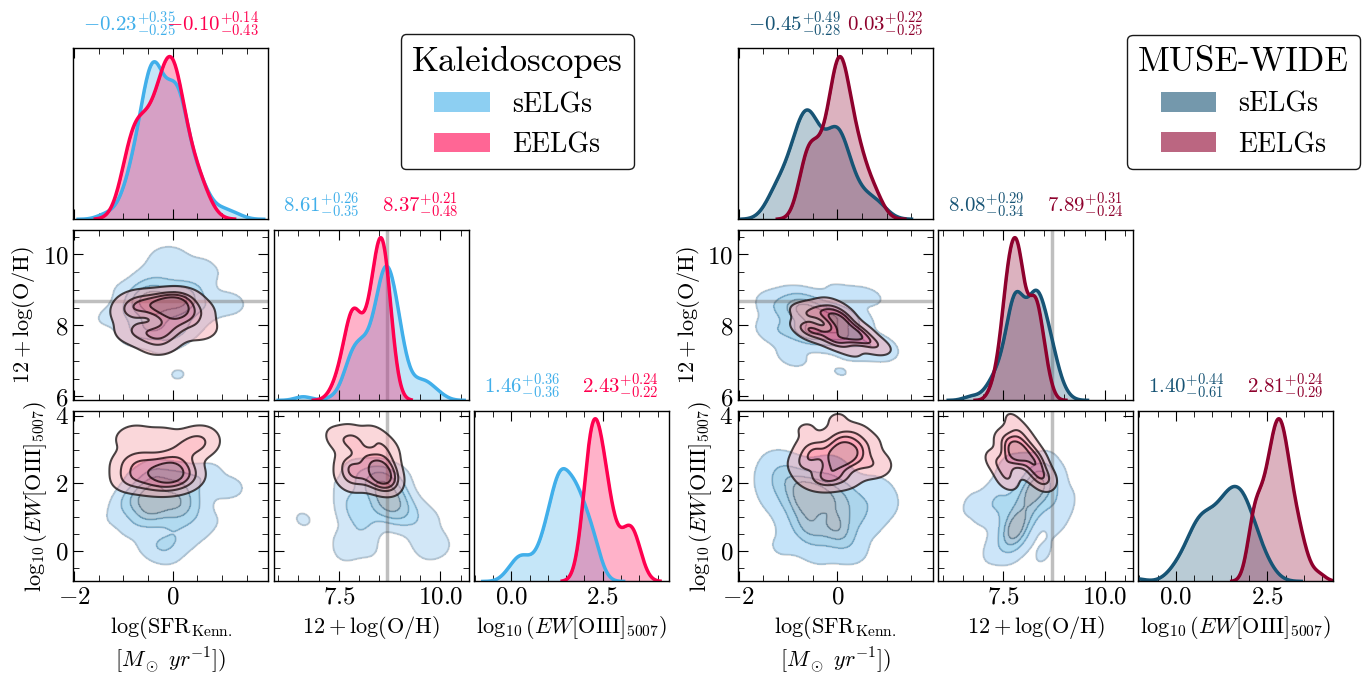

In [73]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.offsetbox import AnchoredText

SOLAR_Z = 8.69  # 12 + log(O/H) solar
COLS   = ['logSFR', 'Z_dir_gen', 'log_oiii_ew']
LABELS = [
    r'$\log(\mathrm{SFR_{Kenn.}}$'+'\n'+r'$[M_\odot\ yr^{-1}])$',
    r'$12+\log(\mathrm{O/H})$',
    r'$\log_{10}(EW\mathrm{[OIII]_{5007}})$',
]
N      = len(COLS)
LEVELS = 5
GAP    = 1   # number of empty columns between the two corner plots

STYLES = {
    'KS': {'non': '#41afea', 'pea': '#ff004f'},
    'MW': {'non': '#175475ff', 'pea': '#8e012dff'},
}

# ── Precompute log EW ─────────────────────────────────────────────────────────
# PEAS_MASK    = (np.log10(MASTER_CLEAN['oiii5007_ew']) > 2) | \
#                (np.log10(MASTER_CLEAN['hbeta_ew']) > 1)
# PEAS         = MASTER_CLEAN[PEAS_MASK].copy()
# NONPEAS      = MASTER_CLEAN[~PEAS_MASK].copy()
PEAS['log_oiii_ew']    = np.log10(PEAS['oiii5007_ew'])
NONPEAS['log_oiii_ew'] = np.log10(NONPEAS['oiii5007_ew'])

# MW_PEAS_MASK = (np.log10(MUSEWIDE_CLEAN['WFoiii5007_ew']) > 2) | \
#                (np.log10(MUSEWIDE_CLEAN['WFhbeta_ew']) > 1)
# MW_PEAS      = MUSEWIDE_CLEAN[MW_PEAS_MASK].copy()
# MW_NONPEAS   = MUSEWIDE_CLEAN[~MW_PEAS_MASK].copy()
MW_PEAS['log_oiii_ew']    = np.log10(MW_PEAS['WFoiii5007_ew'])
MW_NONPEAS['log_oiii_ew'] = np.log10(MW_NONPEAS['WFoiii5007_ew'])

# ── Single flat GridSpec: N + GAP + N columns, N rows ─────────────────────────
fig = plt.figure(figsize=(14, 6.5))

total_cols = N + GAP + N
gs = gridspec.GridSpec(
    N, total_cols,width_ratios=[1]*N + [0.3] + [1]*N,  # shrink the gap column
    hspace=0.06, wspace=0.03,
    left=0.07, right=0.97, top=0.92, bottom=0.10,
)

# Build axes arrays by indexing gs directly
def make_axes_from_gs(col_offset):
    axes = [[None]*N for _ in range(N)]
    legend_ax = None
    for row in range(N):
        for col in range(N):
            if col <= row:
                axes[row][col] = fig.add_subplot(gs[row, col_offset + col])
            elif row == 0 and col == N-1:
                # Top-right cell — use for label + legend
                legend_ax = fig.add_subplot(gs[0:2, col_offset + 1: col_offset + N])
                legend_ax.set_axis_off()
    return axes, legend_ax

axes_ks, leg_ax_ks = make_axes_from_gs(0)
axes_mw, leg_ax_mw = make_axes_from_gs(N + GAP)

# ── Sharing: do it after all axes exist ───────────────────────────────────────
def apply_sharing(axes):
    # x: share each column's cells with the bottom cell of that column
    for col in range(N):
        ref = axes[N-1][col]
        for row in range(col, N-1):
            axes[row][col].sharex(ref)
    # y: share each row's off-diagonal cells with the leftmost (col=0)
    for row in range(1, N):
        ref = axes[row][0]
        for col in range(1, row):
            axes[row][col].sharey(ref)

apply_sharing(axes_ks)
apply_sharing(axes_mw)

# ── Fill ──────────────────────────────────────────────────────────────────────
def fill_corner(axes, nonpeas_df, peas_df, style_key, survey_label):
    c_non = STYLES[style_key]['non']
    c_pea = STYLES[style_key]['pea']

    for row in range(N):
        for col in range(N):
            ax = axes[row][col]
            if ax is None:
                continue

            xcol = COLS[col]
            ycol = COLS[row]

            if row == col:
                sns.kdeplot(nonpeas_df[xcol], ax=ax, color=c_non, fill=True, alpha=0.3)
                sns.kdeplot(nonpeas_df[xcol], ax=ax, color=c_non, lw=2.5)
                sns.kdeplot(peas_df[xcol],    ax=ax, color=c_pea,fill=True, alpha=0.3)
                sns.kdeplot(peas_df[xcol],    ax=ax, color=c_pea, lw=2.5)
                ax.set_ylim(bottom=0)
                ax.yaxis.set_visible(False)

                # Calculate and display stats for nonpeas
                data_non = nonpeas_df[xcol]
                cleaned_data_non = data_non[~np.isnan(data_non)]
                if cleaned_data_non.size > 0:
                    q1_non, med_non, q3_non = np.percentile(cleaned_data_non, [25, 50, 75])
                    upper_err_non = q3_non - med_non
                    lower_err_non = med_non - q1_non
                    stat_text_non = fr'${med_non:.2f}^{{+{upper_err_non:.2f}}}_{{-{lower_err_non:.2f}}}$'
                    ax.text(0.05, 1.05, stat_text_non,
                            ha='left', va='bottom', transform=ax.transAxes,
                            color=c_non, fontsize=15, fontweight='bold', clip_on=False)

                # Calculate and display stats for peas
                data_pea = peas_df[xcol]
                cleaned_data_pea = data_pea[~np.isnan(data_pea)]
                if cleaned_data_pea.size > 0:
                    q1_pea, med_pea, q3_pea = np.percentile(cleaned_data_pea, [25, 50, 75])
                    upper_err_pea = q3_pea - med_pea
                    lower_err_pea = med_pea - q1_pea
                    stat_text_pea = fr'${med_pea:.2f}^{{+{upper_err_pea:.2f}}}_{{-{lower_err_pea:.2f}}}$'
                    ax.text(0.95, 1.05, stat_text_pea,
                            ha='right', va='bottom', transform=ax.transAxes,
                            color=c_pea, fontsize=15, fontweight='bold', clip_on=False)

            else:
                sns.kdeplot(x=nonpeas_df[xcol], y=nonpeas_df[ycol], ax=ax,
                            color=c_non, fill=True, alpha=0.4, levels=LEVELS, zorder=0)
                sns.kdeplot(x=nonpeas_df[xcol], y=nonpeas_df[ycol], ax=ax,
                            color='k', lw=0.8, fill=False, alpha=0.15, levels=LEVELS, zorder=1)
                sns.kdeplot(x=peas_df[xcol], y=peas_df[ycol], ax=ax,
                            color=c_pea, fill=True, alpha=0.45, levels=LEVELS, zorder=2)
                sns.kdeplot(x=peas_df[xcol], y=peas_df[ycol], ax=ax,
                            color='k', lw=0.8, fill=False, alpha=0.7, levels=LEVELS, zorder=3)
                


                # Add inside fill_corner, after the KDE plotting in each cell:
                if ycol == 'Z_dir_gen' and row != col:
                    ax.axhline(SOLAR_Z, color='gray', lw=2.5, alpha=0.5, zorder=0)
                if xcol == 'Z_dir_gen' and row == col:
                    ax.axvline(SOLAR_Z, color='gray', lw=2.5, alpha=0.5, zorder=0)

            # x labels/ticks: bottom row only
            if row == N - 1:
                ax.set_xlabel(LABELS[col], fontsize=16)
            else:
                ax.set_xlabel('')
                ax.tick_params(axis='x', labelbottom=False,labelsize=18)

            # y labels/ticks: leftmost column, off-diagonal only
            if col == 0 and row != 0:
                ax.set_ylabel(LABELS[row], fontsize=16)
                ax.tick_params(axis='y', labelleft=True,labelsize=18)
            else:
                ax.set_ylabel('')
                ax.tick_params(axis='y', labelleft=False,labelsize=18)

    # Survey label in top-left cell
    at = AnchoredText(survey_label, loc='upper right',
                      prop=dict(size=12, fontweight='bold'),
                      frameon=True, pad=0.4)
    at.patch.set_boxstyle("round,pad=0.1")
    at.patch.set_edgecolor('black')
    at.patch.set_linewidth(1.5)
    at.patch.set_facecolor('white')
    at.patch.set_alpha(0.8)
    # axes[0][0].add_artist(at)

fill_corner(axes_ks, NONPEAS,    PEAS,    'KS', 'Kaleidoscopes')
fill_corner(axes_mw, MW_NONPEAS, MW_PEAS, 'MW', 'MUSE-WIDE')

for axes in [axes_ks, axes_mw]:
    col = COLS.index('Z_dir_gen')
    for row in range(col, N):
        axes[row][col].axvline(SOLAR_Z, color='gray', lw=2.5, alpha=0.5, zorder=0)

for col in range(N):
    for row in range(col, N):
        xlim = axes_ks[row][col].get_xlim()
        axes_mw[row][col].set_xlim(xlim)
        if row != col:
            ylim = axes_ks[row][col].get_ylim()
            axes_mw[row][col].set_ylim(ylim)

# ── Legend ────────────────────────────────────────────────────────────────────



for leg_ax, label, style_key in [
    (leg_ax_ks, 'Kaleidoscopes', 'KS'),
    (leg_ax_mw, 'MUSE-WIDE',     'MW'),
]:
    pop_handles = [
        Patch(facecolor=STYLES[style_key]['non'], alpha=0.6, label='sELGs'),
        Patch(facecolor=STYLES[style_key]['pea'], alpha=0.6, label='EELGs'),
    ]
    pos = leg_ax.get_position()
    mid_x = (pos.x0 + pos.x1) / 1.83
    mid_y = (pos.y0 + pos.y1) / 1.55

    leg = fig.legend(handles=pop_handles,
                     title=label,
                     loc='center',
                     bbox_to_anchor=(mid_x, mid_y),
                     bbox_transform=fig.transFigure,
                     ncol=1, fontsize=20,
                     title_fontsize=25,
                     frameon=True, edgecolor='black',
                     facecolor='white', framealpha=0.9)
    leg.get_title().set_fontweight('bold')

all_axes = [ax for row in axes_ks + axes_mw for ax in row if ax is not None]
pf.fix_plot(all_axes)

for axes in [axes_ks, axes_mw]:
    for col in range(N):
        axes[N-1][col].tick_params(axis='x', labelsize=18)
    for row in range(1, N):
        axes[row][0].tick_params(axis='y', labelsize=18)


plt.savefig('figs/metals_sfr_corner.pdf',
            bbox_inches='tight', dpi=500,
            facecolor='white', format='pdf')

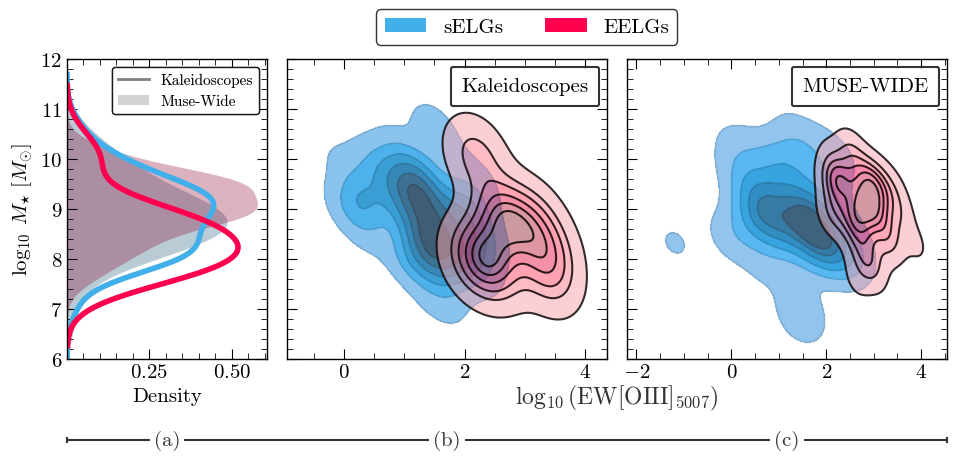

In [74]:
masscat = Table(ascii.read('ELGS_withmasses.csv'))
masscat_short = Table([masscat['object_id'], masscat['logmstellar'],masscat['logmstellar_err']],names=('object_id','logmstellar','logmstellar_error'))

PEAS_MASSES = join(masscat_short, PEAS)
NONPEAS_MASSES = join(masscat_short, NONPEAS)

fig, ax = pf.create_plot((2,3))
ax2 = fig.add_axes((1.1,0,1.6,1),sharey=ax)
ax3 = fig.add_axes((2.8,0,1.6,1),sharey=ax)
plt.setp(ax2.get_yticklabels(), visible=False)
plt.setp(ax3.get_yticklabels(), visible=False)

ax.set_xlabel('Density')
ax.set_ylabel(r'$\log_{10}\;M_{\star}\;[M_{\odot}]$')
ax2.set_xlabel(r'$\log_{10}(EW\mathrm{[OIII]_{5007}})$')

#######################################
# AXIS 1 #
#######################################

##### KALEIDOSCOPE #####
sns.kdeplot(y=NONPEAS_MASSES['logmstellar'], ax=ax, c='#41afea', lw=4, label='sELGs')
sns.kdeplot(y=PEAS_MASSES['logmstellar'], ax=ax, c='#ff004f', lw=4, label='EELGs')

##### MUSEWIDE #####
sns.kdeplot(y=MW_NONPEAS['STELLAR_MASS'], ax=ax, color="#175475ff", lw=0, label='sELGs', fill=True, alpha=0.3, zorder=-10,)
sns.kdeplot(y=MW_PEAS['STELLAR_MASS'], ax=ax, color="#8e012dff", lw=0, label='EELGs', fill=True, alpha=0.3,zorder=-10,)

#######################################
# AXIS 2 #
#######################################

LEVELS = 7

##### KALEIDOSCOPE #####
sns.kdeplot(x=np.log10(NONPEAS_MASSES['oiii5007_ew']), y=NONPEAS_MASSES['logmstellar'], ax=ax2, color='#41afea', label='sELGs', fill=True, alpha=1, zorder=-10, levels=LEVELS)
sns.kdeplot(x=np.log10(NONPEAS_MASSES['oiii5007_ew']), y=NONPEAS_MASSES['logmstellar'], ax=ax2, color='k', lw=1, fill=False, alpha=0.1, zorder=-8, levels=LEVELS)
sns.kdeplot(x=np.log10(PEAS_MASSES['oiii5007_ew']), y=PEAS_MASSES['logmstellar'], ax=ax2, color='#ff004f', label='EELGs', fill=True, alpha=0.5, zorder=10, levels=LEVELS)
sns.kdeplot(x=np.log10(PEAS_MASSES['oiii5007_ew']), y=PEAS_MASSES['logmstellar'], ax=ax2, color='k', lw=1, fill=False, alpha=0.8, zorder=10, levels=LEVELS)

#######################################
# AXIS 3 #
#######################################

##### MUSEWIDE #####
sns.kdeplot(x=np.log10(MW_NONPEAS['WFoiii5007_ew']), y=MW_NONPEAS['STELLAR_MASS'], ax=ax3, color='#175475ff', label='sELGs', fill=True, alpha=1, zorder=-10, levels=LEVELS)
sns.kdeplot(x=np.log10(MW_NONPEAS['WFoiii5007_ew']), y=MW_NONPEAS['STELLAR_MASS'], ax=ax3, color='k', lw=1, fill=False, alpha=0.1, zorder=-8, levels=LEVELS)
sns.kdeplot(x=np.log10(MW_PEAS['WFoiii5007_ew']), y=MW_PEAS['STELLAR_MASS'], ax=ax3, color='#8e012dff', label='EELGs', fill=True, alpha=0.5, zorder=10, levels=LEVELS)
sns.kdeplot(x=np.log10(MW_PEAS['WFoiii5007_ew']), y=MW_PEAS['STELLAR_MASS'], ax=ax3, color='k', lw=1, fill=False, alpha=0.8, zorder=10, levels=LEVELS)


##########

from matplotlib.offsetbox import AnchoredText

for ax_, label in [(ax2, r'Kaleidoscopes'), (ax3, 'MUSE-WIDE')]:
    at = AnchoredText(
        label,
        loc='upper right',
        prop=dict(size=15, fontweight='bold'),
        frameon=True,
        pad=0.4,
    )
    at.patch.set_boxstyle("round,pad=0.1")
    at.patch.set_edgecolor('black')
    at.patch.set_linewidth(1.5)
    at.patch.set_facecolor('white')
    at.patch.set_alpha(0.8)
    ax_.add_artist(at)

##########################

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.legend import Legend

# Survey style indicators
survey_handles = [
    Line2D([0], [0], color='grey', lw=2, label=r'Kaleidoscopes'),
    Patch(facecolor='grey', alpha=0.3, label=r'Muse-Wide'),
]
pop_handles = [
    Patch(facecolor='#41afea', label=r'sELGs'),
    Patch(facecolor='#ff004f', label=r'EELGs'),
]

# Population legend — 2 cols, anchored above the whole figure
fig.legend(handles=pop_handles, loc='upper center', ncol=2,
           bbox_to_anchor=(2.3, 1.2), fontsize=15,
           frameon=True, edgecolor='black', facecolor='white', framealpha=0.8)

# Survey legend stays on ax
leg1 = ax.legend(handles=survey_handles, loc='upper right', fontsize=11,
                 frameon=True, edgecolor='black', facecolor='white', framealpha=0.8)

ax.add_artist(leg1)

ax2_pos = ax2.get_position()
ax3_pos = ax3.get_position()
mid_x = (ax2_pos.x0 + ax3_pos.x1) / 2
bottom_y = ax2_pos.y0

fig.text(mid_x, bottom_y - 0.08, r'$\log_{10}(\mathrm{EW}\mathrm{[OIII]_{5007}})$',
         ha='center', va='top', fontsize=17, color='#333333')

# Remove individual xlabels
ax2.set_xlabel('')
ax3.set_xlabel('')



# --- Bottom line with axis-aligned labels ---
ax_positions = [ax, ax2, ax3]
labels = ['(a)', '(b)', '(c)']

# Draw the full line
ax_pos = ax.get_position()
ax3_pos = ax3.get_position()
line_y = ax_pos.y0 - 0.27

fig.add_artist(Line2D(
    [ax_pos.x0, ax3_pos.x1], [line_y, line_y],
    transform=fig.transFigure,
    color='#333333', lw=1.5,
    solid_capstyle='butt'  # flat caps
))

# Place labels with white background to create the break
for axis, label in zip(ax_positions, labels):
    pos = axis.get_position()
    mid_x = (pos.x0 + pos.x1) / 2
    fig.text(mid_x, line_y, label,
             ha='center', va='center',
             fontsize=15, color='#333333',
             bbox=dict(facecolor='white', edgecolor='none', pad=3))

cap_height = 0.015  # adjust to taste

for x in [ax_pos.x0, ax3_pos.x1]:
    fig.add_artist(Line2D(
        [x, x], [line_y - cap_height/2, line_y + cap_height/2],
        transform=fig.transFigure,
        color='#333333', lw=1.5,
    ))

ax.set_ylim(6,12)
ax.set_xticks([0.25,0.5])

pf.fix_plot([ax,ax2,ax3])

plt.savefig('figs/massex.pdf', bbox_inches='tight', dpi=500,
            facecolor='white', format='pdf')

In [75]:
from astroquery.vizier import Vizier

# Query by catalog ID
v = Vizier(columns=["*"])  # "*" = all columns
catalog_list = v.get_catalogs("J/A+A/578/A105")  # replace with your catalog ID
zCOSMOS = catalog_list[0]  # first table in the catalog

In [76]:
def plot_gps(axis, MARKERSIZE = 10):
    brunkerPeas = ascii.read('../cigale_analysis/brunkerPeas.csv')
    # ax.scatter(brunkerPeas['x'], brunkerPeas['y'], color="#d856db", marker='<', label=r'Brunker+2020: $0.2<z<0.4$', edgecolors='k')
    axis.errorbar(brunkerPeas['x'], brunkerPeas['y'], mfc="#d856db", fmt='o', ms=MARKERSIZE,
                label=r'Brunker+2020: $0.2<z<0.4$', mec='k', yerr=np.abs(np.random.normal(0,0.08,size=len(brunkerPeas['y']))),
                ecolor='None', capsize=2)

    yangBlues = ascii.read('../cigale_analysis/yangPs.csv')
    # ax.scatter(yangBlues['x'], yangBlues['y'], color="#77aca2", marker='^', label=r'Yang+2017: $0.1<z<0.36$', edgecolors='k')

    axis.errorbar(yangBlues['x'], yangBlues['y'], mfc="#77aca2", fmt='o', ms=MARKERSIZE,
                label=r'Yang+2017: $0.1<z<0.36$', mec='k', yerr=np.abs(np.random.normal(0,0.08,size=len(yangBlues['y']))),
                ecolor='None', capsize=2)

    yangPeas = ascii.read('../cigale_analysis/yangBlues.csv')
    # ax.scatter(yangPeas['x'], yangPeas['y'], color="#4c33c8", marker='>', label=r'Yang+2017: $z\sim0$', edgecolors='k')

    axis.errorbar(yangPeas['x'], yangPeas['y'], mfc="#4c33c8", fmt='o', ms=MARKERSIZE,
                label=r'Yang+2017: $z\sim0$', mec='k', yerr=np.abs(np.random.normal(0,0.02,size=len(yangPeas['y']))),
                ecolor='None', capsize=2)


In [77]:
for p in [PEAS_MASSES,NONPEAS_MASSES]:
    p['logsSFR'] = p['logSFR']-p['logmstellar']
    p['t_univ'] = cosmo.age(p['z']).value
    p['logsSFRms'] = (0.84-0.026*p['t_univ'])*p['logmstellar']-(6.51-0.11*p['t_univ'])-p['logmstellar']
    p['dMS'] = p['logsSFR']-p['logsSFRms']

for p in [MW_PEAS,MW_NONPEAS]:
    p['logsSFR'] = p['logSFR']-p['STELLAR_MASS']
    p['t_univ'] = cosmo.age(p['z']).value
    p['logsSFRms'] = (0.84-0.026*p['t_univ'])*p['STELLAR_MASS']-(6.51-0.11*p['t_univ'])-p['STELLAR_MASS']
    p['dMS'] = p['logsSFR']-p['logsSFRms']

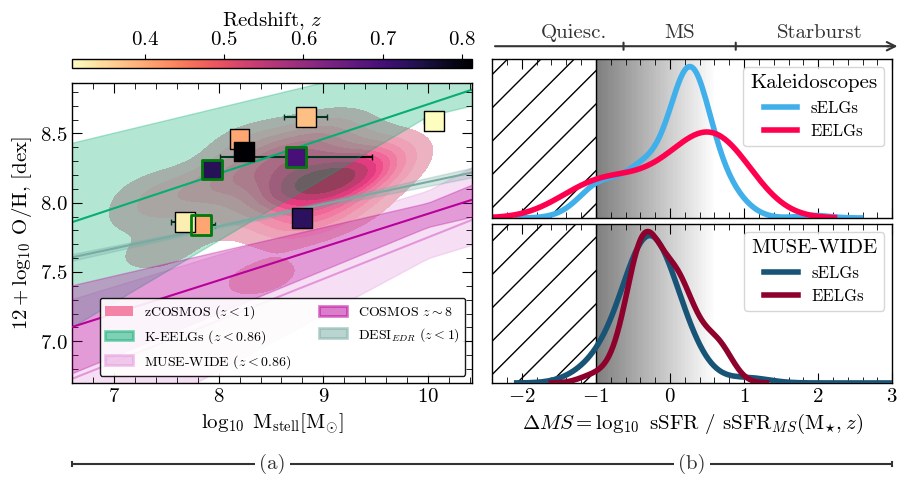

In [ ]:

colors = "#ff4681"
fig,ax = pf.create_plot()

#######################################
# AXIS 1 #
#######################################

sns.kdeplot(x=zCOSMOS['logMs'], y=zCOSMOS['Ab(O)'], color="#f383a7", fill=True,zorder=-12, ax=ax, alpha=1)
# sns.kdeplot(x=MW_PEAS['STELLAR_MASS'], y=MW_PEAS['Z_dir_gen'])
# plot_gps(ax, 3)

cmap = ax.scatter(PEAS_MASSES['logmstellar'], PEAS_MASSES['Z_dir_gen'], c=PEAS_MASSES['z'],edgecolor='k', marker='s', s=200, zorder=10, cmap='magma_r')
ax.errorbar(PEAS_MASSES['logmstellar'], PEAS_MASSES['Z_dir_gen'],xerr=2*PEAS_MASSES['logmstellar_error'], yerr=PEAS_MASSES['Z_dir_gen_err'], ecolor='k', capsize=2, color='none', zorder=-10)
# cmap = ax.scatter(NONPEAS_MASSES['logmstellar'], NONPEAS_MASSES['Z_dir_gen'], c=NONPEAS_MASSES['z'],edgecolor='k', marker='s', s=100, zorder=10, cmap='magma_r')
# ax.errorbar(NONPEAS_MASSES['logmstellar'], NONPEAS_MASSES['Z_dir_gen'],xerr=NONPEAS_MASSES['logmstellar_error'], yerr=NONPEAS_MASSES['Z_dir_gen_err'], ecolor='k', capsize=2, color='none', zorder=-10)

flag = PEAS_MASSES['nev3426_flux']/PEAS_MASSES['nev3426_flux_err'] > 5
ax.scatter(PEAS_MASSES['logmstellar'][flag], PEAS_MASSES['Z_dir_gen'][flag], marker='s', s=200, zorder=10, facecolor='None', edgecolor="#007c0e", lw=2)

ax.set_ylabel(r'$12+\log_{10}\;$O/H, [dex]')
ax.set_xlabel(r'$\log_{10}\;\mathrm{M}_{\mathrm{stell}} [\mathrm{M}_{\odot}]$')

ax.set_xlim(6.6)
ax.set_ylim(6.7,ax.get_ylim()[-1])

cax = fig.add_axes((0,1.05,1,0.03))
plt.colorbar(cmap, cax=cax, label='Redshift, $z$', orientation='horizontal')
cax.tick_params(bottom=False, top=True, labeltop=True, labelbottom=False)
cax.xaxis.set_label_position('top')


# legend_elements = [
#     Patch(facecolor='#f383a7', edgecolor='none', alpha=1, label=r'zCOSMOS ($z<1$)'),
#     Line2D([0], [0], marker='s', color='none', markerfacecolor='gray',
#            markeredgecolor='k', markersize=10, label='K-EELGs'),
#     Line2D([0], [0], marker='s', color='none', markerfacecolor='none',
#            markeredgecolor='#007c0e', markeredgewidth=2, markersize=10,
#            label=r'NeV ($>5\sigma$)'),
# ]

legend_elements = [
    Patch(facecolor='#f383a7', edgecolor='none', label=r'zCOSMOS ($z<1$)'),
    # Use Patch for models to represent the "fill_between" + line aesthetic
    Patch(facecolor='#07ae73', alpha=0.5, edgecolor='#07ae73', lw=2, label=r'K-EELGs ($z<0.86$)'),
    Patch(facecolor='#e496db', alpha=0.5, edgecolor='#e496db', lw=2, label=r'MUSE-WIDE ($z<0.86$)'),
    Patch(facecolor='#b9009a', alpha=0.5, edgecolor='#b9009a', lw=2, label=r'COSMOS $z \sim 8$'),
    Patch(facecolor='#77aca2', alpha=0.5, edgecolor='#77aca2', lw=2, label=r'DESI$_{EDR}$ ($z<1$)'),
    # Keep the NeV flag if you want to keep that specific data highlight
    # Line2D([0], [0], marker='s', color='none', markerfacecolor='none',
    #        markeredgecolor='#007c0e', markeredgewidth=2, markersize=10,
    #        label=r'NeV ($>5\sigma$)'),
]

leg = ax.legend(handles=legend_elements, loc='lower right', fontsize=10,
          frameon=True, framealpha=0.9, edgecolor='k', ncols=2)

leg.set_zorder(100)

# ax.legend(handles=legend_elements, loc='lower right', fontsize=10,
#           frameon=True, framealpha=1, edgecolor='k')

# def model_OH(log_mass_draw, gamma_g, Z_g10):
#     """Eq. 2:  predicted 12+log(O/H) given log stellar mass."""
#     return gamma_g * (log_mass_draw - 10.0) + Z_g10

grid = np.linspace(5,12,100)
# ax.plot(grid, model_OH(grid, 0.25,8.71), zorder=30, alpha=0.5, lw=4)
# ax.plot(grid, model_OH(grid, 0.24,9-1.08), zorder=30, alpha=0.5, lw=4)
# ax.plot(grid, model_OH(grid, 0.16,7.83+2*0.16), zorder=30, alpha=0.5, lw=4)


def plot_model_OH(ax, mass_range, gamma_g, gamma_err, Z_g10, Z_err, color='blue', pivot=10.0, zorder=1,**kwargs):
    g_min, g_plus = (gamma_err, gamma_err) if not isinstance(gamma_err, (list, tuple)) else gamma_err
    z_min, z_plus = (Z_err, Z_err) if not isinstance(Z_err, (list, tuple)) else Z_err

    y_val = gamma_g * (mass_range - pivot) + Z_g10
    
    y1 = (gamma_g - g_min) * (mass_range - pivot) + (Z_g10 - z_min)
    y2 = (gamma_g - g_min) * (mass_range - pivot) + (Z_g10 + z_plus)
    y3 = (gamma_g + g_plus) * (mass_range - pivot) + (Z_g10 - z_min)
    y4 = (gamma_g + g_plus) * (mass_range - pivot) + (Z_g10 + z_plus)
    
    y_low = np.minimum.reduce([y1, y2, y3, y4])
    y_high = np.maximum.reduce([y1, y2, y3, y4])
    
    ax.plot(mass_range, y_val, color=color, zorder=zorder)
    ax.fill_between(mass_range, y_low, y_high, color=color, alpha=0.3, zorder=zorder,**kwargs)
    
    return ax

## this work
plot_model_OH(ax,grid, 0.25,(0.136/2,0.395/2),8.71,(0.179/2,0.675/2), color="#07ae73", label=r'K-EELGs ($z<0.86$)')
plot_model_OH(ax,grid, 0.3,(0.14/2,0.21/2),7.75,(0.3/2,0.675/2), color="#e496db", label=r'MW-EELGs ($z<0.86$)', zorder=-50)
plot_model_OH(ax,grid, 0.24,(0.13/2,0.14/2),(9-1.08),(0.19/2,0.16/2), color="#b9009a", label=r'COSMOS z~8', zorder=10)
plot_model_OH(ax,grid, 0.16,0.01,7.83,0.01,pivot=8, color="#77aca2", label=r'DESI-EDR ($z<1$)')

#######################################
# AXIS 2 #
#######################################

ax2 = fig.add_axes((1.05,0.55,1,0.53))
plt.setp(ax2.get_yticklabels(), visible=False)
plt.setp(ax2.get_xticklabels(), visible=False)
ax2.set_yticks([])

##### KALEIDOSCOPE #####
sns.kdeplot(x=NONPEAS_MASSES['dMS'], ax=ax2, c='#41afea', lw=4, label='sELGs')
sns.kdeplot(x=PEAS_MASSES['dMS'], ax=ax2, c='#ff004f', lw=4, label='EELGs')

ax2.legend(title='Kaleidoscopes', fontsize=12)

xlim = ax2.get_xlim()          # e.g. (-2.4, 3) after ax3.set_xlim propagates via sharex
bar_y = 1.08                   # in axes-fraction coordinates (above the top spine)
arrow_y = 1.11

# The bracket line (no arrowhead)
ax2.annotate('', xy=(1.0, bar_y), xytext=(0.0, bar_y),
             xycoords='axes fraction', textcoords='axes fraction',
             arrowprops=dict(arrowstyle='-', color='#333333', lw=1.5),
             annotation_clip=False)

# The arrow at the right end
ax2.annotate('', xy=(1.02, bar_y), xytext=(0.98, bar_y),
             xycoords='axes fraction', textcoords='axes fraction',
             arrowprops=dict(arrowstyle='->', color='#333333', lw=1.5),
             annotation_clip=False)

# Tick marks at the three regime boundaries
# Map data-space positions to axes fraction for tick placement
x_min, x_max = xlim
ticks_data = [-1.0, 0.6]   # boundaries between Quiesc/MS and MS/Starburst
for xd in ticks_data:
    xf = (xd - x_min) / (x_max - x_min)
    ax2.annotate('', 
                 xy=(xf, bar_y - 0.04),   # extend below the bar
                 xytext=(xf, bar_y + 0.04),  # extend above the bar
                 xycoords='axes fraction', textcoords='axes fraction',
                 arrowprops=dict(arrowstyle='-', color='#333333', lw=1.5),
                 annotation_clip=False)

# Labels for the three regimes
label_positions = [
    ((-2.4 + -1.0) / 2, 'Quiesc.'),   # centre of quiescent zone
    ((-1.0 +  0.6) / 2, 'MS'),         # centre of main-sequence zone
    (( 0.6 +  3.0) / 2, 'Starburst'),  # centre of starburst zone
]

for xd, label in label_positions:
    xf = (xd - x_min) / (x_max - x_min)
    ax2.text(xf, arrow_y, label,
             transform=ax2.transAxes,
             ha='center', va='bottom',
             fontsize=15, color='#333333')

#######################################
# AXIS 3 #
#######################################

ax3 = fig.add_axes((1.05,0,1,0.53), sharex=ax2)
plt.setp(ax3.get_yticklabels(), visible=False)
ax3.set_yticks([])

##### MUSEWIDE #####
# clean = MW_NONPEAS['logsSFR']<-4
sns.kdeplot(x=MW_NONPEAS['dMS'], ax=ax3, color="#175475ff", lw=4, label='sELGs', fill=False, alpha=1, zorder=10,)
sns.kdeplot(x=MW_PEAS['dMS'], ax=ax3, color="#8e012dff", lw=4, label='EELGs', fill=False, alpha=1,zorder=10,)

ax3.set_xlim(-2.4,3)
ax3.legend(title='MUSE-WIDE', fontsize=12)

for a in [ax2,ax3]:
    lims = a.get_ylim()
    a.set_ylim(*lims)
    a.fill_betweenx([-100,100],-100,-1,hatch='/', facecolor='None', zorder=-15)
    # a.fill_betweenx([-100,100],-1,0.6, facecolor='k', zorder=-15, alpha=0.05)
    steps = 50
    x_values = np.linspace(-1, 0.6, steps)
    alphas = np.linspace(0.5, 0, steps)

    for i in range(steps - 1):
        a.fill_betweenx([-100, 100], x_values[i], x_values[i+1], 
                        facecolor='k', alpha=alphas[i], zorder=-15, edgecolor='none')

#######################################
# TEXT #
#######################################
# ax3.set_xlabel(r'$\log_{10}$ sSFR [yr$^{-1}$]')
ax3.set_xlabel(r'$\Delta MS = \log_{10}$ sSFR / sSFR$_{MS}(\mathrm{M}_{\star},z)$')

# ax.text(8.3,7.25,'Kaleidoscopes EELGs',bbox=dict(facecolor='white', edgecolor='k', pad=4))
# ax2.text(-7.1,.5,'Kaleidoscopes',bbox=dict(facecolor='white', edgecolor='k', pad=4))
# ax3.text(-7.05,.7,'MUSE-WIDE',bbox=dict(facecolor='white', edgecolor='k', pad=4))

ax_positions = [ax, ax3]
labels = ['(a)', '(b)']

# Draw the full line
ax_pos = ax.get_position()
ax3_pos = ax3.get_position()
line_y = ax_pos.y0 - 0.27

fig.add_artist(Line2D(
    [ax_pos.x0, ax3_pos.x1], [line_y, line_y],
    transform=fig.transFigure,
    color='#333333', lw=1.5,
    solid_capstyle='butt'  # flat caps
))

# Place labels with white background to create the break
for axis, label in zip(ax_positions, labels):
    pos = axis.get_position()
    mid_x = (pos.x0 + pos.x1) / 2
    fig.text(mid_x, line_y, label,
             ha='center', va='center',
             fontsize=15, color='#333333',
             bbox=dict(facecolor='white', edgecolor='none', pad=3))

cap_height = 0.015  # adjust to taste

for x in [ax_pos.x0, ax3_pos.x1]:
    fig.add_artist(Line2D(
        [x, x], [line_y - cap_height/2, line_y + cap_height/2],
        transform=fig.transFigure,
        color='#333333', lw=1.5,
    ))

pf.fix_plot([ax,ax2,ax3])
plt.savefig('figs/massev.png', bbox_inches='tight', dpi=600,
            facecolor='white')

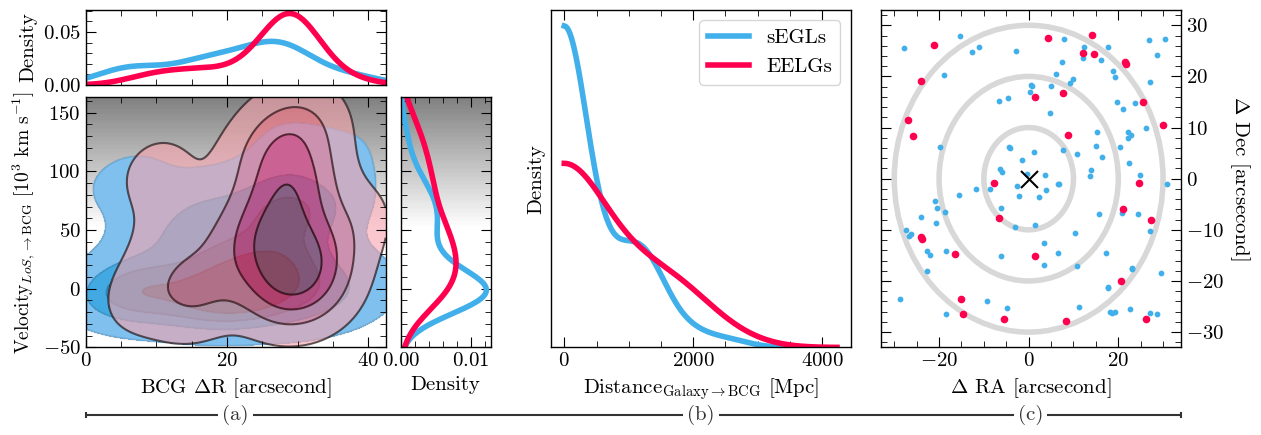

In [17]:
fig, ax = pf.create_plot((3,2.5))
ax_yhist = fig.add_axes((1.05,0,0.3,1), sharey=ax)
ax_xhist = fig.add_axes((0,1.05,1,0.3), sharex=ax)
plt.setp(ax_yhist.get_yticklabels(), visible=False)
plt.setp(ax_xhist.get_xticklabels(), visible=False)

MASTER_ALL = vstack([PEAS_MASSES,NONPEAS_MASSES])

colors=['#41afea','#ff004f']
for ii, tab in enumerate([NONPEAS_MASSES,PEAS_MASSES]):
    sns.kdeplot(x=tab['angular_separation_arcsec'], y=tab['los_velocity_kms']/1e3, levels=5, 
                color=colors[ii], alpha=1-0.4*ii,fill=True, ax=ax,zorder=-5+ii, clip=((0,30*np.sqrt(2)),(None,164498.94/1e3)))
    sns.kdeplot(x=tab['angular_separation_arcsec'], y=tab['los_velocity_kms']/1e3, levels=5, 
                color='k', alpha=0.5*ii+0.1, ax=ax, zorder=-5+ii,clip=((0,30*np.sqrt(2)),(None,164498.94/1e3)))

    sns.kdeplot(y=tab['los_velocity_kms']/1e3, color=colors[ii], fill=False, lw=4, ax=ax_yhist)
    sns.kdeplot(x=tab['angular_separation_arcsec'], color=colors[ii], fill=False, lw=4,ax=ax_xhist, clip=(0,30*np.sqrt(2)))

ax_yhist.set_ylim(*ax_yhist.get_ylim())
ax_yhist.set_xlim(*ax_yhist.get_xlim())

steps = 50
y_values = np.linspace(164498.94/1e3,53127.777/1e3,  steps)
alphas = np.linspace(0.5, 0, steps)

for i in range(steps - 1):
    ax.fill_between([-100, 100], y_values[i], y_values[i+1], 
                    facecolor='k', alpha=alphas[i], zorder=-15, edgecolor='none')
    ax_yhist.fill_between([-100, 100], y_values[i], y_values[i+1], 
                facecolor='k', alpha=alphas[i], zorder=-15, edgecolor='none')
    
# ax.fill_between([-100,100],164498.94/1e3,500, hatch='/', facecolor='White', zorder=-1, edgecolor='k')

ax.set_xlim(0,30*np.sqrt(2))
ax.set_ylim(-50,163)

ax.set_xlabel(r'BCG $\Delta$R [arcsecond]')
# ax.set_ylabel(r'LoS$_{\mathrm{\to BCG}}$ Vel. [$10^3$ km s$^{-1}$]')
ax.set_ylabel(r'Velocity$_{LoS, \mathrm{\to BCG}}$ [$10^3$ km s$^{-1}$]', fontsize=14)




############################################################################
############################################################################
############################################################################


ax2 = fig.add_axes((1.55,0,1,1.35))
labels = 'sEGLs','EELGs'

for ii, tab in enumerate([NONPEAS_MASSES,PEAS_MASSES]):
    reflected = np.concatenate([tab['distance_3d_mpc'],-tab['distance_3d_mpc']])
    sns.kdeplot(x=reflected, color=colors[ii], fill=False, lw=4, ax=ax2, label=labels[ii], clip=(0,None))

ax2.set_xlabel(r'Distance$_{\mathrm{Galaxy} \to \mathrm{BCG}}$ [Mpc]')
ax2.legend()

############################################################################
############################################################################
############################################################################


ax3 = fig.add_axes((2.65,0,1,1.35))

ax3.set_ylabel(r'$\Delta$ Dec [arcsecond]', rotation=-90, va="top", labelpad=20)
ax3.set_xlabel(r'$\Delta$ RA [arcsecond]')

# ax3.yaxis.tick_right()
ax3.tick_params(left=True, right=True, labelleft=False, labelright=True)
ax3.yaxis.set_label_position("right")

radii = [10, 20, 30]
for r in radii:
    circle = Circle((0, 0), r, fill=False, edgecolor='gray', linestyle='-',linewidth=4, zorder=-12, alpha=0.3)
    ax3.add_patch(circle)


for ii, tab in enumerate([NONPEAS_MASSES,PEAS_MASSES]):
    galaxy_coords = SkyCoord(tab['ra'], tab['dec'], unit='deg', frame='icrs')
    cluster_coords = SkyCoord(tab['cluster_ra'], tab['cluster_dec'], unit='deg', frame='icrs')

    # d_coords = galaxy_coords-cluster_coords
    delta_ra_arcsec = (cluster_coords.ra -galaxy_coords.ra).arcsec * np.cos(galaxy_coords.dec.radian)
    delta_dec_arcsec = (cluster_coords.dec -galaxy_coords.dec).arcsec
    ax3.scatter(delta_ra_arcsec,delta_dec_arcsec, color=colors[ii], s=(10*ii+10))

ax3.scatter([0],[0], marker='x', s=150, color='k')

ax2.set_yticks([])


############################################################################
############################################################################
############################################################################

ax_positions = [ax, ax2,ax3]
labels = ['(a)', '(b)','(c)']

# Draw the full line
ax_pos = ax.get_position()
ax3_pos = ax3.get_position()
line_y = ax_pos.y0 - 0.27

fig.add_artist(Line2D(
    [ax_pos.x0, ax3_pos.x1], [line_y, line_y],
    transform=fig.transFigure,
    color='#333333', lw=1.5,
    solid_capstyle='butt'  # flat caps
))

# Place labels with white background to create the break
for axis, label in zip(ax_positions, labels):
    pos = axis.get_position()
    mid_x = (pos.x0 + pos.x1) / 2
    fig.text(mid_x, line_y, label,
             ha='center', va='center',
             fontsize=15, color='#333333',
             bbox=dict(facecolor='white', edgecolor='none', pad=3))

cap_height = 0.015  # adjust to taste

for x in [ax_pos.x0, ax3_pos.x1]:
    fig.add_artist(Line2D(
        [x, x], [line_y - cap_height/2, line_y + cap_height/2],
        transform=fig.transFigure,
        color='#333333', lw=1.5,
    ))

############################################################################
############################################################################
############################################################################


pf.fix_plot([ax, ax_xhist,ax_yhist,ax2, ax3])
plt.savefig('figs/lss.png', bbox_inches='tight', dpi=600,
            facecolor='white')

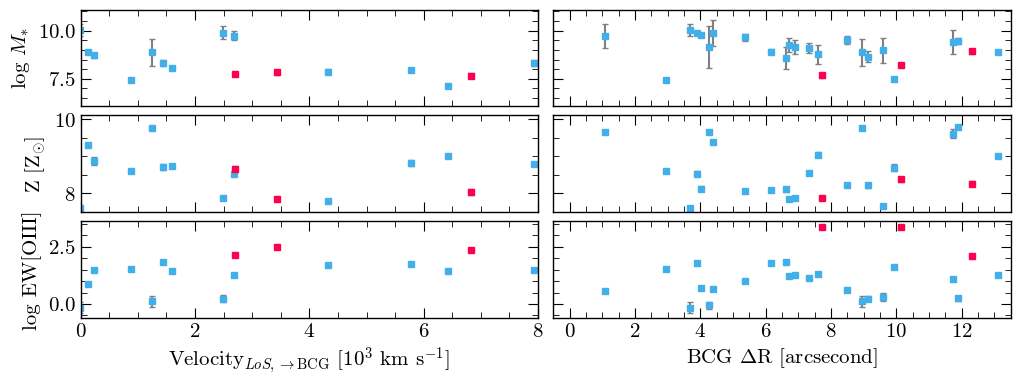

In [18]:
fig, axs = plt.subplots(ncols=2, nrows=3,figsize=(12, 4), sharex='col', sharey='row')
fig.subplots_adjust(wspace=0.1/3, hspace=0.1)
axes = axs.flatten()
for i in range(4):
    plt.setp(axes[i].get_xticklabels(), visible=False)
    if i % 2 != 0:
        plt.setp(axes[i].get_yticklabels(), visible=False)
plt.setp(axes[5].get_yticklabels(), visible=False)

axes[0].set_ylabel(r'log $M_{*}$')
axes[2].set_ylabel(r'Z [Z$_{\odot}$]')
axes[4].set_ylabel(r'log EW[OIII]')

axes[1].set_xlim([-0.5,13.5])


axes[4].set_xlabel(r'Velocity$_{LoS, \mathrm{\to BCG}}$ [$10^3$ km s$^{-1}$]')
axes[5].set_xlabel(r'BCG $\Delta$R [arcsecond]')

keys = ['logmstellar','Z_dir_gen','log_oiii_ew']
keys2 = ['los_velocity_kms','angular_separation_arcsec']

NONPEAS_MASSES['log_oiii_ew_err'] = 0.432*NONPEAS_MASSES['oiii5007_ew_err']/NONPEAS_MASSES['oiii5007_ew']
PEAS_MASSES['log_oiii_ew_err'] = 0.432*PEAS_MASSES['oiii5007_ew_err']/PEAS_MASSES['oiii5007_ew']

NONPEAS_MASSES['logmstellar_err'] = NONPEAS_MASSES['logmstellar_error']
PEAS_MASSES['logmstellar_err'] = PEAS_MASSES['logmstellar_error']

for i,a in enumerate(axs):
    for ii,ax in enumerate(a):
        for iii, tab in enumerate([NONPEAS_MASSES,PEAS_MASSES]):
            normaliser = 10**(3-3*ii)# makes kms in 10^3
            ax.errorbar(tab[keys2[ii]]/normaliser, tab[keys[i]], yerr=2*tab[keys[i]+'_err'], fmt='s', capsize=2, ecolor='gray', ms=4, color=colors[iii])

axes[4].set_xlim(0,8)
axes[0].set_ylim(6.1,11.1)
axes[2].set_ylim(7.5,10.1)

pf.fix_plot(axes)
plt.savefig('figs/cluster_structure.pdf', bbox_inches='tight', dpi=600,
            facecolor='white')


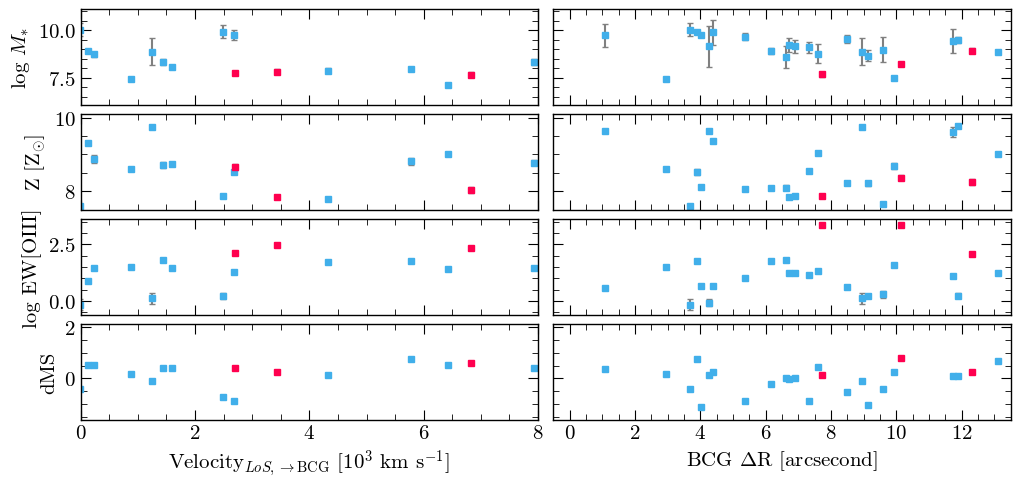

In [19]:
colors=['#41afea','#ff004f']

fig, axs = plt.subplots(ncols=2, nrows=4,figsize=(12, 5.33), sharex='col', sharey='row')
fig.subplots_adjust(wspace=0.1/3, hspace=0.1)
axes = axs.flatten()

# Hide x-tick labels for the top three rows
for i in range(6):
    plt.setp(axes[i].get_xticklabels(), visible=False)

# Hide y-tick labels for the right-hand column
for i in [1, 3, 5, 7]:
    plt.setp(axes[i].get_yticklabels(), visible=False)


axes[0].set_ylabel(r'log $M_{*}$')
axes[2].set_ylabel(r'Z [Z$_{\odot}$]')
axes[4].set_ylabel(r'log EW[OIII]')
axes[6].set_ylabel(r'dMS') # Y-label for the new row

axes[1].set_xlim([-0.5,13.5])

# Move x-labels to the new bottom row
axes[6].set_xlabel(r'Velocity$_{LoS, \mathrm{\to BCG}}$ [$10^3$ km s$^{-1}$]')
axes[7].set_xlabel(r'BCG $\Delta$R [arcsecond]')

keys = ['logmstellar','Z_dir_gen','log_oiii_ew', 'dMS'] # Added 'dMS'
keys2 = ['los_velocity_kms','angular_separation_arcsec']

# Add dummy error for dMS as it is negligible
NONPEAS_MASSES['dMS_err'] = 0
PEAS_MASSES['dMS_err'] = 0

NONPEAS_MASSES['log_oiii_ew_err'] = 0.432*NONPEAS_MASSES['oiii5007_ew_err']/NONPEAS_MASSES['oiii5007_ew']
PEAS_MASSES['log_oiii_ew_err'] = 0.432*PEAS_MASSES['oiii5007_ew_err']/PEAS_MASSES['oiii5007_ew']

NONPEAS_MASSES['logmstellar_err'] = NONPEAS_MASSES['logmstellar_err']
PEAS_MASSES['logmstellar_err'] = PEAS_MASSES['logmstellar_error']

for i,a in enumerate(axs):
    for ii,ax in enumerate(a):
        for iii, tab in enumerate([NONPEAS_MASSES,PEAS_MASSES]):
            normaliser = 10**(3-3*ii)# makes kms in 10^3
            ax.errorbar(tab[keys2[ii]]/normaliser, tab[keys[i]], yerr=2*tab[keys[i]+'_err'], fmt='s', capsize=2, ecolor='gray', ms=4, color=colors[iii])

axes[6].set_xlim(0,8) # Set x-limit on the new bottom row
axes[0].set_ylim(6.1,11.1)
axes[2].set_ylim(7.5,10.1)
# You may want to add a ylim for the new dMS plot, e.g.:
# axes[6].set_ylim(-1.5, 1.5)

pf.fix_plot(axes)
plt.savefig('figs/cluster_structure_modified.png', bbox_inches='tight', dpi=600,
            facecolor='white')

In [20]:
def get_R23(sel):
    R23 = ((sel['oiii5007_flux']+sel['oiii4959_flux']+sel['oii3726_flux']+sel['oii3729_flux'])/sel['hbeta_flux']).data
    num_r23 = np.array((sel['oiii5007_flux'],sel['oiii4959_flux'],sel['oii3726_flux'],sel['oii3729_flux']))
    num_r23_err = np.array((sel['oiii5007_flux_err'],sel['oiii4959_flux_err'],sel['oii3726_flux_err'],sel['oii3729_flux_err']))
    R23_err = (np.sqrt((np.sqrt(np.sum(num_r23_err**2,axis=0))/np.sum(num_r23, axis=0))**2 + (sel['hbeta_flux_err'].data/sel['hbeta_flux'].data)**2)*R23)
    return R23, R23_err

def get_O32(sel):
    num_o32 = np.array(sel['oiii5007_flux'])
    num_o32_err = np.array(sel['oiii5007_flux_err'])
    denom_o32 = np.array([sel['oii3729_flux'],sel['oii3726_flux']])
    denom_o32_err = np.array([sel['oii3729_flux_err'],sel['oii3726_flux_err']])
    O32 = num_o32/np.sum(denom_o32, axis=0)
    O32_err = np.sqrt((num_o32_err/num_o32)**2+(np.sqrt(np.sum(denom_o32_err**2, axis=0))/np.sum(denom_o32, axis=0))**2)*O32
    return O32, O32_err

def get_R23_MW(sel):
    R23 = ((sel['WFoiii5007_flux']+sel['WFoiii4959_flux']+sel['WFoii_flux'])/sel['WFhbeta_flux']).data
    num_r23 = np.array((sel['WFoiii5007_flux'],sel['WFoiii4959_flux'],sel['WFoii_flux']))
    num_r23_err = np.array((sel['WFoiii5007_flux_err'],sel['WFoiii4959_flux_err'],sel['WFoii_flux_err']))
    R23_err = (np.sqrt((np.sqrt(np.sum(num_r23_err**2,axis=0))/np.sum(num_r23, axis=0))**2 + (sel['WFhbeta_flux_err'].data/sel['WFhbeta_flux'].data)**2)*R23)
    return R23, R23_err

def get_O32_MW(sel):
    num_o32 = np.array(sel['WFoiii5007_flux'])
    num_o32_err = np.array(sel['WFoiii5007_flux_err'])
    denom_o32 = np.array([sel['WFoii_flux']])
    denom_o32_err = np.array([sel['WFoii_flux_err']])
    O32 = num_o32/np.sum(denom_o32, axis=0)
    O32_err = np.sqrt((num_o32_err/num_o32)**2+(np.sqrt(np.sum(denom_o32_err**2, axis=0))/np.sum(denom_o32, axis=0))**2)*O32
    return O32, O32_err

#41afea
#ff004f
#0f84f3ff
#c1003dff


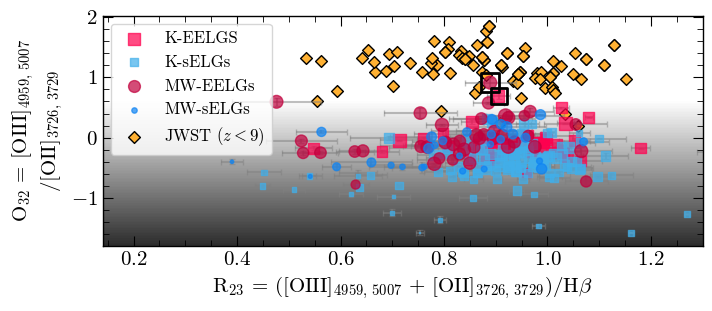

In [21]:
fig, ax = pf.create_plot((6,2.3))

ALL_K = [PEAS,NONPEAS]
ALL_MW = [MW_PEAS,MW_NONPEAS]

colors_all=('#41afea','#ff004f'),("#0f84f3ff","#c1003dff")
names_all = ('K-EELGS','K-sELGs'),('MW-EELGs','MW-sELGs')
markers = ['s','o']

functions = (get_R23,get_O32),(get_R23_MW,get_O32_MW)

CEERS = Table(ascii.read('CEERS.csv'))

for i,A in enumerate([ALL_K,ALL_MW]):
    colors = colors_all[i]
    names = names_all[i]
    pref = 'WF' if i==1 else ''
    for ii,B in enumerate(A):
        R,O = functions[i]
        R23, R23_err = R(B)
        O32, O32_err = O(B)
        print(colors[ii])
        mask = ((R23_err/R23)<0.2) & ((O32_err/O32)<0.2)

        EWSHAPE = 100*(np.log10(B[pref+'oiii5007_ew'][mask])/4 +0.05)
        # print(np.max(EWSHAPE))

        ax.errorbar(np.log10(R23)[mask],np.log10(O32)[mask], xerr=(0.432*R23_err/R23)[mask], 
                    yerr = (0.432*O32_err/O32)[mask], fmt='None', ecolor='gray', capsize=2,
                    c='None', alpha=0.5, zorder=-5)
        ax.scatter(np.log10(R23)[mask],np.log10(O32)[mask], marker=markers[i],
                    c=colors[1-ii], alpha=0.7, s=EWSHAPE, label=names[ii])
        # ax.errorbar(np.log10(R23),np.log10(O32), fmt='o', ecolor=None)

        mask2 = (np.log10(B[pref+'oiii5007_ew'][mask])>np.log10(200))&(np.log10(O32)[mask]>np.log10(4))
        ax.scatter(np.log10(R23)[mask][mask2],np.log10(O32)[mask][mask2], marker='s',
                    edgecolor='k', s=EWSHAPE[mask2]*2, facecolor='None', lw=2, zorder=10)

ax.scatter(CEERS['x']-1, CEERS['y']-1, zorder=-10, marker='D', color="#ffb133", edgecolor='k', label=r'JWST ($z<9$)')

ax.set_xlim([0.14,1.3])
ax.set_ylim(*ax.get_ylim())

ax.set_xlabel(r'R$_{23}$ = ([OIII]$_{4959,\,5007}$ + [OII]$_{3726,\,3729}$)/H$\beta$')
ax.set_ylabel(r'O$_{32}$ = [OIII]$_{4959,\,5007}$'+'\n'+r'/[OII]$_{3726,\,3729}$')

steps = 100
y_values = np.linspace(-2,np.log10(4),  steps)
alphas = np.linspace(0.9, 0, steps)

for i in range(steps - 1):
    ax.fill_between([-100, 100], y_values[i], y_values[i+1], 
                    facecolor='k', alpha=alphas[i], zorder=-15, edgecolor='none')
    ax_yhist.fill_between([-100, 100], y_values[i], y_values[i+1], 
                facecolor='k', alpha=alphas[i], zorder=-15, edgecolor='none')

ax.legend(fontsize=12)

pf.fix_plot([ax])

plt.savefig('figs/r23o32.png', bbox_inches='tight', dpi=600,
            facecolor='white')

Main Density: 9.20e-04 ± 1.25e-04 Mpc^-3
MW Density:   9.69e-04 ± 1.14e-04 Mpc^-3


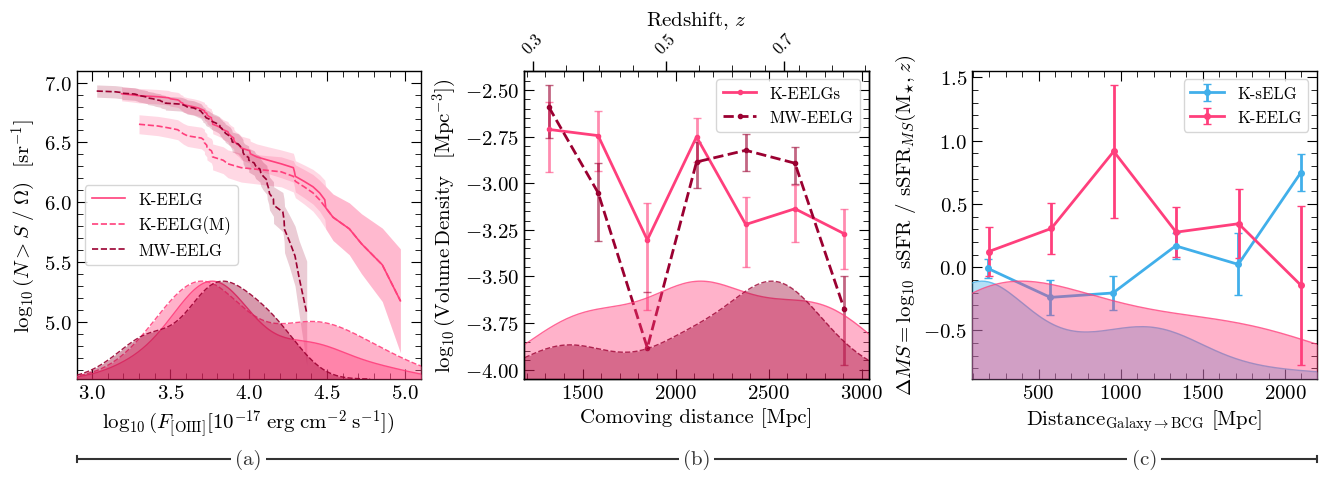

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u

fig, axs = plt.subplots(ncols=3, figsize=(16, 4))
fig.subplots_adjust(wspace=0.3)

# --- Colours ---
c_np, c_p, c_mwnp, c_mwp = '#41afea', "#FF3F7C", '#0f84f3ff', "#9b0031ff"

# =============================================================
# LEFT: log N / log S
# =============================================================
ax = axs[0]

def log_n_log_s(ax, flux_col, table, color, label, omega_sr, ls='-'):
    fluxes = np.array(table[flux_col], dtype=float)
    fluxes = fluxes[np.isfinite(fluxes) & (fluxes > 0)]
    s_sorted  = np.sort(fluxes)
    log_s     = np.log10(s_sorted)
    log_n     = np.log10(np.arange(len(s_sorted), 0, -1) / omega_sr)

    # Poisson error in log space at every point
    n_raw    = np.arange(len(s_sorted), 0, -1)   # raw counts before omega normalisation
    log_err  = 1 / (np.log(10) * np.sqrt(n_raw))

    ax.plot(log_s, log_n, color=color, ls=ls, lw=1.2, zorder=2, label=label)
    ax.fill_between(log_s, log_n - log_err, log_n + log_err,
                    color=color, alpha=0.2, lw=0, zorder=1)
    
    ax.set_xlim(*ax.get_xlim())
    
    log_s_all = np.log10(fluxes) # Use all points for the KDE

    # Add KDE to background
    ax_kde = ax.twinx()
    sns.kdeplot(log_s_all, ax=ax_kde, color=color, fill=True, alpha=0.4, lw=0, zorder=-15)
    sns.kdeplot(log_s_all, ax=ax_kde, color=color, fill=False, alpha=0.9, lw=1, zorder=-15, ls=ls)

    # add_reflected_kde(ax_kde,log_s_all, color)
    _, y_max = ax_kde.get_ylim()
    ax_kde.set_ylim(0, y_max * 3) # Forces the KDE to stay in the bottom 3rd
    ax_kde.set_axis_off()

    

arcmin2_to_sr = (np.pi / (180 * 60))**2
omega_main = 79  * arcmin2_to_sr
omega_mw   = 100 * arcmin2_to_sr

# log_n_log_s(ax, 'oiii5007_flux',   NONPEAS,    c_np,   'Non-PEA',    omega_main)
log_n_log_s(ax, 'oiii5007_flux',   PEAS,       c_p,    'K-EELG',        omega_main)
log_n_log_s(ax, 'oiii5007_flux',   PEAS_MASSES,       c_p,    'K-EELG(M)',        omega_main, ls='--')
# log_n_log_s(ax, 'WFoiii5007_flux', MW_NONPEAS, c_mwnp, 'MW Non-PEA', omega_mw, ls='--')
log_n_log_s(ax, 'WFoiii5007_flux', MW_PEAS,    c_mwp,  'MW-EELG',     omega_mw, ls='--')



ax.set_xlabel(r'$\log_{10}(F_{\rm [OIII]} [10^{-17}\;\mathrm{erg}\;\mathrm{cm}^{-2}\;\mathrm{s}^{-1}])$')
ax.set_ylabel(r'$\log_{10}(N > F)$')
ax.legend(fontsize=12, loc='center left')
ax.set_ylabel(r'$\log_{10}(N > S \; / \; \Omega)$  [sr$^{-1}$]')

ax.set_xlim(2.9,5.1)

# =============================================================
# MIDDLE: comoving volume density of PEAs + twin redshift axis
# =============================================================
ax = axs[1]

def get_distances(table):
    z = np.array(table['z'], dtype=float)
    z = z[np.isfinite(z) & (z > 0)]
    return cosmo.comoving_distance(z).to(u.Mpc).value

d_peas = get_distances(PEAS)
d_mwpeas = get_distances(MW_PEAS)

# Common bin edges over combined range
n_bins = 7
d_min = min(d_peas.min(), d_mwpeas.min())
d_max = max(d_peas.max(), d_mwpeas.max())
d_bins = np.linspace(d_min, d_max, n_bins + 1)
d_centres = 0.5 * (d_bins[:-1] + d_bins[1:])

# Full-sky shell volumes in Mpc^3 — scale by (Omega / 4pi) if solid angle known
# Solid angles in steradians
# 1 arcmin^2 = (pi / (180*60))^2 sr
arcmin2_to_sr = (np.pi / (180 * 60))**2

omega_main = 79  * arcmin2_to_sr   # survey 1
omega_mw   = 100 * arcmin2_to_sr   # MW survey

shell_vol_main = (omega_main / (4 * np.pi)) * (4 * np.pi / 3) * (d_bins[1:]**3 - d_bins[:-1]**3)
# simplifies to:
# shell_vol_main = (omega_main / 3) * (d_bins[1:]**3 - d_bins[:-1]**3)
shell_vol_mw   = (omega_mw   / 3) * (d_bins[1:]**3 - d_bins[:-1]**3)

def plot_volume_density(ax, d_mpc, shell_vol, d_bins, d_centres, color, label, ls='-', limit=False):
    counts, _ = np.histogram(d_mpc, bins=d_bins)
    mask = counts > 0
    density  = counts[mask] / shell_vol[mask]
    d_err    = np.sqrt(counts[mask]) / shell_vol[mask]   # Poisson error
    log_dens = np.log10(density)
    # Asymmetric log-space errorbars: propagate σ_φ/φ = 1/√N
    log_err_lo = log_dens - np.log10(density - d_err)
    log_err_hi = np.log10(density + d_err) - log_dens
    ax.errorbar(d_centres[mask], log_dens,
                # yerr=[log_err_lo, log_err_hi],
                color=color, ls=ls, marker='o', ms=3,
                capsize=3, lw=2, label=label,)
    
    ax.errorbar(d_centres[mask], log_dens,
                yerr=[log_err_lo, log_err_hi],
                color='None', ls=ls, marker='o', ms=3,
                capsize=3, lw=2, alpha=0.6, ecolor=color)
    
    # Background KDE for distances
    ax_kde = ax.twinx()
    sns.kdeplot(d_mpc, ax=ax_kde, color=color, fill=True, alpha=0.4, lw=0, zorder=-15)
    sns.kdeplot(d_mpc, ax=ax_kde, color=color, fill=False, alpha=0.8, lw=1, zorder=-15, ls=ls)
    _, y_max = ax_kde.get_ylim()
    ax_kde.set_ylim(0, y_max * 3) 
    ax_kde.set_axis_off()

plot_volume_density(ax, d_peas,   shell_vol_main, d_bins, d_centres, c_p,   'K-EELGs')
plot_volume_density(ax, d_mwpeas, shell_vol_mw,   d_bins, d_centres, c_mwp, 'MW-EELG', ls='--',)

ax.set_xlim(d_min, d_max)
ax.set_xlabel(r'Comoving distance [Mpc]')
ax.set_ylabel(r'$\log_{10}(\mathrm{Volume\,Density}\,$  [Mpc$^{-3}$])')
ax.legend(fontsize=12)

# Twin redshift axis
ax_z = ax.twiny()
# After building ax_z
lw = ax.spines['bottom'].get_linewidth()
for spine in ax_z.spines.values():
    spine.set_linewidth(lw)
ax_z.tick_params(axis='x', width=lw)
z_candidates = np.array([0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0])
d_candidates = cosmo.comoving_distance(z_candidates).to(u.Mpc).value
mask_t = (d_candidates >= d_min) & (d_candidates <= d_max)
ax_z.set_xlim(d_min, d_max)
ax_z.set_xticks(d_candidates[mask_t])
ax_z.set_xticklabels([f'{z:.2g}' for z in z_candidates[mask_t]], fontsize=12, rotation=45)
ax_z.set_xlabel(r'Redshift, $z$', fontsize=15)

def get_average_density(d_mpc, shell_vols, d_bins):
    counts, _ = np.histogram(d_mpc, bins=d_bins)
    total_n = np.sum(counts)
    total_v = np.sum(shell_vols)
    avg_density = total_n / total_v
    std_error = np.sqrt(total_n) / total_v
    
    return avg_density, std_error

rho_main, err_main = get_average_density(d_peas, shell_vol_main, d_bins)
rho_mw, err_mw = get_average_density(d_mwpeas, shell_vol_mw, d_bins)

print(f"Main Density: {rho_main:.2e} ± {err_main:.2e} Mpc^-3")
print(f"MW Density:   {rho_mw:.2e} ± {err_mw:.2e} Mpc^-3")

# =============================================================
# RIGHT: cluster distance vs sSFR — binned mean ± SE (main survey only)
# =============================================================
ax = axs[2]

def binned_mean_se(ax, table, color, label, n_bins=7, marker='o', ls='-'):
    d = np.array(table['distance_3d_mpc'], dtype=float)
    s = np.array(table['dMS'],         dtype=float)
    finite = np.isfinite(d) & np.isfinite(s)
    d, s = d[finite], s[finite]
    bins = np.linspace(d.min(), d.max(), n_bins + 1)
    centres, means, ses = [], [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        sel = (d >= lo) & (d < hi)
        if sel.sum() < 2:
            continue
        vals = s[sel]
        centres.append(0.5 * (lo + hi))
        means.append(vals.mean())
        ses.append(vals.std(ddof=1) / np.sqrt(len(vals)))
    centres, means, ses = map(np.array, (centres, means, ses))
    ax.errorbar(centres, means, yerr=ses,
                color=color, marker=marker, ms=4, ls=ls,
                capsize=3, lw=2, label=label, zorder=10)
    
    ax.set_xlim(*ax.get_xlim())
    
    # Background KDE
    ax_kde = ax.twinx()
    sns.kdeplot(d, ax=ax_kde, color=color, fill=True, alpha=0.4, lw=0, zorder=-15)
    sns.kdeplot(d, ax=ax_kde, color=color, fill=False, alpha=0.8, lw=1, zorder=-15)
    _, y_max = ax_kde.get_ylim()
    ax_kde.set_ylim(0, y_max * 3)
    ax_kde.set_axis_off()
    
binned_mean_se(ax, NONPEAS_MASSES, c_np, 'K-sELG')
binned_mean_se(ax, PEAS_MASSES,    c_p,  'K-EELG')

# ax.set_xlabel(r'$d_{\rm cluster}$ [Mpc]')
ax.set_xlabel(r'Distance$_{\mathrm{Galaxy} \to \mathrm{BCG}}$ [Mpc]')
# ax.set_ylabel(r'$\log_{10}(\rm sSFR \ / \ yr^{-1})$')
ax.set_ylabel(r'$\Delta MS = \log_{10}$ sSFR / sSFR$_{MS}(\mathrm{M}_{\star},z)$')
ax.legend(fontsize=12)

# ax.set_ylim(-11.1,-6.4)

pf.fix_plot(axs)
pf.fix_plot([ax_z], tickdir='out')

############################################################################
############################################################################
############################################################################

ax_positions = axs[0],axs[1],axs[2]
labels = ['(a)', '(b)','(c)']

# Draw the full line
ax_pos = axs[0].get_position()
ax3_pos = axs[2].get_position()
line_y = ax_pos.y0 - 0.2

fig.add_artist(Line2D(
    [ax_pos.x0, ax3_pos.x1], [line_y, line_y],
    transform=fig.transFigure,
    color='#333333', lw=1.5,
    solid_capstyle='butt'  # flat caps
))

# Place labels with white background to create the break
for axis, label in zip(ax_positions, labels):
    pos = axis.get_position()
    mid_x = (pos.x0 + pos.x1) / 2
    fig.text(mid_x, line_y, label,
             ha='center', va='center',
             fontsize=15, color='#333333',
             bbox=dict(facecolor='white', edgecolor='none', pad=3))

cap_height = 0.015  # adjust to taste

for x in [ax_pos.x0, ax3_pos.x1]:
    fig.add_artist(Line2D(
        [x, x], [line_y - cap_height/2, line_y + cap_height/2],
        transform=fig.transFigure,
        color='#333333', lw=1.5,
    ))

############################################################################
############################################################################
############################################################################



plt.savefig('figs/pea_survey_comparison.pdf', dpi=300, bbox_inches='tight')


True

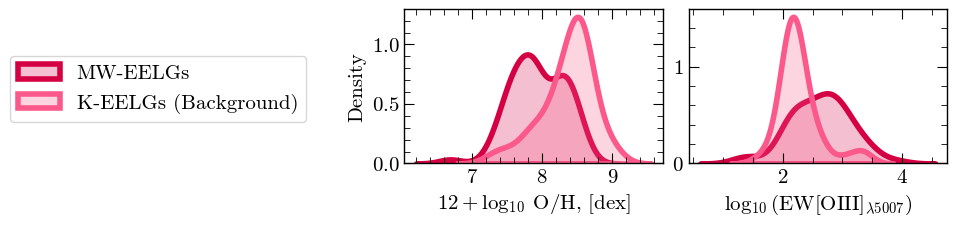

In [23]:
fig, axs = plt.subplots(ncols=2, figsize=(7, 2))
mask = PEAS['z']>(PEAS['zcluster']+0.05)
mask2 = PEAS['z']<(PEAS['zcluster']-0.02)
# front = PEAS[mask2]
front = MW_PEAS
back  = PEAS[mask]

colors = ["#d50044","#fb588b"]
labels = ['MW-EELGs','K-EELGs (Background)']

# for i,f in enumerate([front, back, MW_PEAS]):
for i,f in enumerate([front, back]):
    sns.kdeplot(x=f['Z_dir_gen'], ax =axs[0], color=colors[i], lw=4, fill=True, label=labels[i])
    sns.kdeplot(x=f['log_oiii_ew'], ax =axs[1], color=colors[i], lw=4, fill=True)

ax.legend()

axs[0].set_xlabel(r'$12+\log_{10}\;$O/H, [dex]')
axs[1].set_xlabel(r'$\log_{10}($EW[OIII]$_{\lambda5007}$)')
axs[0].set_ylabel('Density')
axs[1].set_ylabel('')

fig.subplots_adjust(wspace=0.1)
fig.legend(bbox_to_anchor=(0,0.7))

pf.fix_plot(axs)

In [24]:
cmembers = PEAS[PEAS['cluster_member']==1]

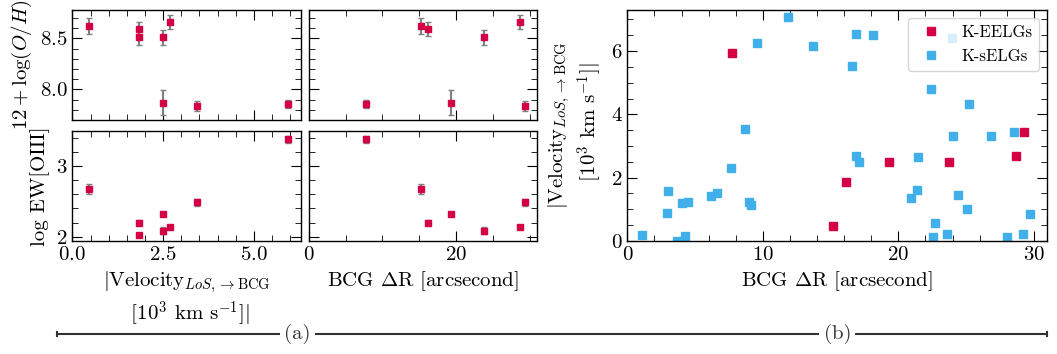

In [32]:
velsep = ((cmembers['z']-cmembers['zcluster'])/(1+cmembers['zcluster'])*speedoflight)

fig, axs = plt.subplots(ncols=2, nrows=2,figsize=(6, 3), sharex='col', sharey='row')
fig.subplots_adjust(wspace=0.1/3, hspace=0.1)
axes = axs.flatten()
for i in range(2):
    plt.setp(axes[i].get_xticklabels(), visible=False)
    if i % 2 != 0:
        plt.setp(axes[i].get_yticklabels(), visible=False)
# plt.setp(axes[5].get_yticklabels(), visible=False)

# axes[0].set_ylabel(r'log $M_{*}$')
axes[0].set_ylabel(r'$12+\log (O/H)$')
axes[2].set_ylabel(r'log EW[OIII]')

# axes[1].set_xlim([-0.5,13.5])


axes[2].set_xlabel(r'$|$Velocity$_{LoS, \mathrm{\to BCG}}$'+'\n'+r' [$10^3$ km s$^{-1}$]$|$')
axes[3].set_xlabel(r'BCG $\Delta$R [arcsecond]')

keys = ['Z_dir_gen','log_oiii_ew']
keys2 = ['abs_los_velocity_kms','angular_separation_arcsec']

cmembers['log_oiii_ew_err'] = 0.432*cmembers['oiii5007_ew_err']/cmembers['oiii5007_ew']
cmembers['abs_los_velocity_kms'] = np.abs(cmembers['los_velocity_kms'])
idx = np.where(cmembers['object_id'] == '24d30m56pt79s-21d55m46pt848s')[0]
cmembers['abs_los_velocity_kms'][idx] = 1849.3463067680098 # fix incorrect [oIII] redshift here - this is one of the manually measured ones


for i,a in enumerate(axs):
    for ii,ax in enumerate(a):
        for iii, tab in enumerate([cmembers]):
            normaliser = 10**(3-3*ii)# makes kms in 10^3
            ax.errorbar(tab[keys2[ii]]/normaliser, tab[keys[i]], yerr=2*tab[keys[i]+'_err'], fmt='s', capsize=2, ecolor='gray', ms=4, color=colors[iii])

axes[2].set_xlim(0,6.3)
axes[3].set_xlim(0,31)

# axes[0].set_ylim(6.1,11.1)
# axes[2].set_ylim(7.5,10.1)

############################################################################
############################################################################
############################################################################

ax3 = fig.add_axes((1.05,.11,0.7,0.77))

ax3.errorbar(cmembers['angular_separation_arcsec'], cmembers['abs_los_velocity_kms']/1e3, fmt='s', capsize=2, ecolor='gray', ms=6, color=colors[0], label='K-EELGs')
ax3.errorbar(NONPEAS['angular_separation_arcsec'], np.abs(NONPEAS['los_velocity_kms'])/1e3, fmt='s', capsize=2, ecolor='gray', ms=6, color='#41afea', label='K-sELGs')
ax3.set_ylim(0,7.3)
ax3.set_xlim(0,31)
ax3.set_ylabel(r'$|$Velocity$_{LoS, \mathrm{\to BCG}}$'+'\n'+r' [$10^3$ km s$^{-1}$]$|$')
ax3.set_xlabel(r'BCG $\Delta$R [arcsecond]')

dummy = fig.add_axes((0.1,0,0.8,1))
dummy.set_visible(False)

############################################################################
############################################################################
############################################################################


ax_positions = [dummy,ax3]
labels = ['(a)', '(b)']

# Draw the full line
ax_pos = ax_positions[0].get_position()
ax3_pos = ax_positions[1].get_position()
line_y = ax_pos.y0 - 0.2

fig.add_artist(Line2D(
    [ax_pos.x0, ax3_pos.x1], [line_y, line_y],
    transform=fig.transFigure,
    color='#333333', lw=1.5,
    solid_capstyle='butt'  # flat caps
))

# Place labels with white background to create the break
for axis, label in zip(ax_positions, labels):
    pos = axis.get_position()
    mid_x = (pos.x0 + pos.x1) / 2
    fig.text(mid_x, line_y, label,
             ha='center', va='center',
             fontsize=15, color='#333333',
             bbox=dict(facecolor='white', edgecolor='none', pad=3))

cap_height = 0.015  # adjust to taste

for x in [ax_pos.x0, ax3_pos.x1]:
    fig.add_artist(Line2D(
        [x, x], [line_y - cap_height/2, line_y + cap_height/2],
        transform=fig.transFigure,
        color='#333333', lw=1.5,
    ))

ax3.legend(fontsize=12, loc='upper right')

pf.fix_plot(axes)
pf.fix_plot([ax3])
plt.savefig('figs/cluster_structure.pdf', bbox_inches='tight', dpi=600,
            facecolor='white')


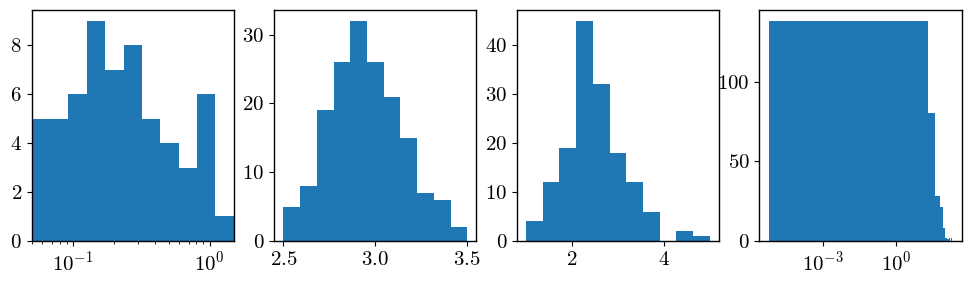

In [67]:
fig, axes = plt.subplots(ncols=4, figsize=(12,3))

MASK = MASTER['EBV_snr']>3
hist = MASTER[MASK]

axes[0].hist(hist['EBV'], bins=np.logspace(np.log10(0.05),np.log10(1.5),12))
axes[0].set_xscale('log')
axes[0].set_xlim([0.05,1.5])

axes[1].hist(MASTER['oiii5007_flux']/MASTER['oiii4959_flux'], bins=np.linspace(2.5,3.5,12))

axes[2].hist(hist['halpha_flux']/hist['hbeta_flux'], bins=np.linspace(1,5,12))

axes[3].hist(MASTER['EBV_snr'])
axes[3].set_xscale('log')


In [69]:
np.sum(MASTER['halpha_flux']>0)

np.int64(162)

In [71]:
np.sum(PEAS['halpha_flux']>0)

np.int64(14)

In [80]:
np.sort(PEAS['oiii5007_ew'])

121.38000356340318
128.03314761257064
135.43359618229172
151.00657203416412
156.4388172682421
159.76602909430386
162.68944189334746
181.56187763912706
189.40154139602552
202.18549159205273
242.14566353067084


In [81]:
MASTER

object_id,ra,dec,z,angdisp,foreground,cluster_member,lensed,Z_dir,Z_dir_e,Z_j19,Z_j19_e,R23,R23_e,mean_vel_disp,sterr_vel_disp,zcluster,name,oiii5007_flux,oiii5007_flux_err,oiii5007_ew,oiii5007_ew_err,oiii5007_centroid,oiii5007_fwhm,oiii5007_vel_disp,oiii4959_flux,oiii4959_flux_err,oiii4959_ew,oiii4959_ew_err,oiii4959_centroid,oiii4959_fwhm,oiii4959_vel_disp,oii3726_flux,oii3726_flux_err,oii3726_ew,oii3726_ew_err,oii3726_centroid,oii3726_fwhm,oii3726_vel_disp,oii3729_flux,oii3729_flux_err,oii3729_ew,oii3729_ew_err,oii3729_centroid,oii3729_fwhm,oii3729_vel_disp,halpha_flux,halpha_flux_err,halpha_ew,halpha_ew_err,halpha_centroid,halpha_fwhm,halpha_vel_disp,hbeta_flux,hbeta_flux_err,hbeta_ew,hbeta_ew_err,hbeta_centroid,hbeta_fwhm,hbeta_vel_disp,hgamma_flux,hgamma_flux_err,hgamma_ew,hgamma_ew_err,hgamma_centroid,hgamma_fwhm,hgamma_vel_disp,hdelta_flux,hdelta_flux_err,hdelta_ew,hdelta_ew_err,hdelta_centroid,hdelta_fwhm,hdelta_vel_disp,hepsilon_flux,hepsilon_flux_err,hepsilon_ew,hepsilon_ew_err,hepsilon_centroid,hepsilon_fwhm,hepsilon_vel_disp,hzeta_flux,hzeta_flux_err,hzeta_ew,hzeta_ew_err,hzeta_centroid,hzeta_fwhm,hzeta_vel_disp,heta_flux,heta_flux_err,heta_ew,heta_ew_err,heta_centroid,heta_fwhm,heta_vel_disp,oiii4363_flux,oiii4363_flux_err,oiii4363_ew,oiii4363_ew_err,oiii4363_centroid,oiii4363_fwhm,oiii4363_vel_disp,neiii_flux,neiii_flux_err,neiii_ew,neiii_ew_err,neiii_centroid,neiii_fwhm,neiii_vel_disp,nii6583_flux,nii6583_flux_err,nii6583_ew,nii6583_ew_err,nii6583_centroid,nii6583_fwhm,nii6583_vel_disp,nii6548_flux,nii6548_flux_err,nii6548_ew,nii6548_ew_err,nii6548_centroid,nii6548_fwhm,nii6548_vel_disp,sii6716_flux,sii6716_flux_err,sii6716_ew,sii6716_ew_err,sii6716_centroid,sii6716_fwhm,sii6716_vel_disp,sii6731_flux,sii6731_flux_err,sii6731_ew,sii6731_ew_err,sii6731_centroid,sii6731_fwhm,sii6731_vel_disp,nev3426_flux,nev3426_flux_err,nev3426_ew,nev3426_ew_err,nev3426_centroid,nev3426_fwhm,nev3426_vel_disp,fevii3760_flux,fevii3760_flux_err,fevii3760_ew,fevii3760_ew_err,fevii3760_centroid,fevii3760_fwhm,fevii3760_vel_disp,heii4686_flux,heii4686_flux_err,heii4686_ew,heii4686_ew_err,heii4686_centroid,heii4686_fwhm,heii4686_vel_disp,hei5876_flux,hei5876_flux_err,hei5876_ew,hei5876_ew_err,hei5876_centroid,hei5876_fwhm,hei5876_vel_disp,flux_HST_F435W,flux_HST_F606W,flux_HST_F814W,flux_Spitzer_I1_3.6,flux_Spitzer_I2_4.5,oii_flux,oii_ew,WFC3_F502N,WFC3_F606W,WFC3_F625W,WFC3_F656N,WFC3_F775W,cluster_key,cluster_fullname,source_dir,cluster_ra,cluster_dec,los_velocity_kms,angular_separation_arcsec,projected_distance_mpc,distance_3d_mpc,EBV,EBV_line,EBV_snr,oiii5007_flux_corr,oiii4959_flux_corr,oii3726_flux_corr,oii3729_flux_corr,halpha_flux_corr,hbeta_flux_corr,hgamma_flux_corr,hdelta_flux_corr,hepsilon_flux_corr,hzeta_flux_corr,heta_flux_corr,oiii4363_flux_corr,neiii_flux_corr,nii6583_flux_corr,nii6548_flux_corr,sii6716_flux_corr,sii6731_flux_corr,nev3426_flux_corr,fevii3760_flux_corr,heii4686_flux_corr,hei5876_flux_corr
str40,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str12,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float6

In [139]:
def get_strongest_line_column(table):
    """
    Identifies the strongest emission line among [OIII], [OII], Hbeta, Halpha, and NII.
    Returns an astropy Column containing the name of the strongest line.
    """
    # Convert to pandas for easier vectorised comparison if it's an astropy Table
    if hasattr(table, 'to_pandas'):
        df = table.to_pandas()
    else:
        df = pd.DataFrame(table)

    # Calculate total fluxes for species with doublets
    # We use .fillna(0) to ensure NaNs don't break the comparison
    fluxes = pd.DataFrame()
    
    # [OIII] Total (5007 + 4959)
    fluxes['[OIII]'] = df['oiii5007_flux'].fillna(0) + df['oiii4959_flux'].fillna(0)
    
    # [OII] Total (The 'oii_flux' column already contains the sum of 3726 and 3729)
    fluxes['[OII]'] = df['oii_flux'].fillna(0)
    
    # H-beta
    fluxes[r'H$\beta$'] = df['hbeta_flux'].fillna(0)
    
    # H-alpha
    fluxes[r'H$\alpha$'] = df['halpha_flux'].fillna(0)
    
    # [NII] Total (6583 + 6548)
    fluxes['[NII]'] = df['nii6583_flux'].fillna(0) + df['nii6548_flux'].fillna(0)
    
    # Identify the column name with the maximum flux for each row
    strongest_line_names = fluxes.idxmax(axis=1)
    
    # Create and return the astropy Column
    return Column(name='strongest_line', data=strongest_line_names.values)

def map_spectro_keys(input_array, name='strongest_line_mapped'):
    """
    Maps non-standard emission line names to the standardized 
    format used in the previous flux analysis.
    """
    # Define the dictionary mapping
    # Adjust this if 'Lya' or 'MgII' should be mapped to something specific
    mapping = {
        'OIII 2': '[OIII]',
        'OII': '[OII]',
        'Ha': r'H$\alpha$',
        'Hb': r'H$\beta$',
        'NII 2': '[NII]',
        'Lya': r'Ly$\alpha$',      # Keep as is or map to 'Lyman-alpha'
        'MgII 1': 'MgII',
        'SII 1': 'SII',
        'HeII': 'HeII',
        '-': 'Unknown'
    }
    
    # Apply the mapping. 
    # .get(x, x) ensures that if a key isn't in our dict, it stays as is.
    standardized_data = [mapping.get(str(x).strip(), x) for x in input_array]
    
    return Column(name=name, data=standardized_data)

In [153]:
z1 = MASTER1['z'].data
lls1 = get_strongest_line_column(MASTER1)

leadlines = Table(ascii.read('../catalogue/leadlines.csv'))
z2 = leadlines['Redshift'].data
lls2 = map_spectro_keys(leadlines['Identification'].data)

allz = np.concatenate([z1,z2])
allident = np.concatenate([lls1,lls2])
smalltab = Table([allz,allident], names=('z','ident'))
smalltab.sort('z')
smalltab = smalltab.group_by('ident')

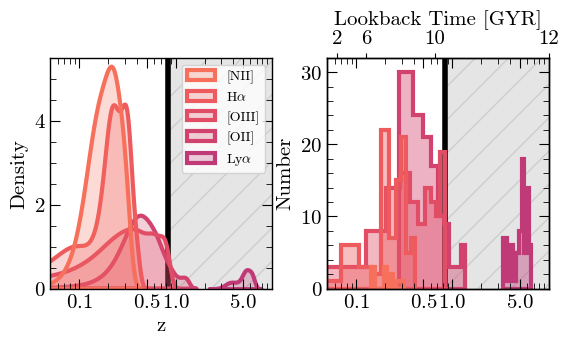

In [175]:
fig, axes = plt.subplots(ncols=3, figsize=(10,3))

axes[0].get_shared_x_axes()._grouper.join(axes[0], axes[1])

cmap = plt.get_cmap('magma_r')
points = np.linspace(0.3,0.7,len(smalltab.groups))
rgba_colors = cmap(points)

all_groups = list(smalltab.groups)
sorted_groups = sorted(all_groups, key=lambda g: np.mean(g['z']))
groups_to_plot = [g for g in sorted_groups if len(g) > 4]

for i, g in enumerate(groups_to_plot):
    line = g['ident'][0]
    sns.kdeplot(x=g['z'], ax=axes[0], linewidth=3, color=rgba_colors[i], label=line, fill='layer', zorder=-i)
    fc = [rgba_colors[i][0],rgba_colors[i][1],rgba_colors[i][2],0.4]
    axes[1].hist(g['z'], facecolor=fc, histtype='stepfilled', lw=3, edgecolor=rgba_colors[i], zorder=-i)

axes[0].set_xscale('log', base=10)
axes[0].set_xlim(0.05,10)


axes[1].set_ylabel('Number')
axes[0].legend(fontsize=10, ncols =1)

for a in [axes[0],axes[1]]:
    tick_locations = [0.1,0.5, 1, 5]
    a.set_xticks(tick_locations)

    import matplotlib.ticker as mticker
    a.get_xaxis().set_major_formatter(mticker.ScalarFormatter())

ax3 = axes[1].twiny()
lookback_time_ticks_gyr = [2, 6, 10, 12]

from astropy.cosmology.funcs import z_at_value
z_for_ticks = [z_at_value(cosmo.lookback_time, t * u.Gyr) for t in lookback_time_ticks_gyr]

ax3.set_xticks(z_for_ticks)
ax3.set_xticklabels([f'{t}' for t in lookback_time_ticks_gyr])
ax3.set_xlabel('Lookback Time [GYR]')
# plt.setp(axes[1].get_xticklabels(), visible=False)

axes[0].set_ylim(0,5.5)
axes[1].set_ylim(0,32)

for a in [axes[0],axes[1]]:
    a.vlines(0.83, -100,100, colors='k', lw=4,zorder=-10)
    a.fill_betweenx([-100,100],0.83,100, zorder=-100, color='k', alpha=0.1, hatch='/', edgecolor='k')


pf.fix_plot(axes)

axes[2].set_visible(False)
fig.subplots_adjust(wspace=0.25)

plt.savefig('figs/zdist.pdf', bbox_inches='tight', dpi=600,
            facecolor='white')

z,ident
float64,object
0.21591195304705546,H\alpha
0.1914528121015917,H\alpha
0.25769297659367485,H\alpha
0.14183738180752403,H\alpha
0.219057728738125,H\alpha
4.15162,H\alpha
5.954,H\alpha
0.22569,H\alpha
3.34665,H\alpha
